# Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection   
  
### Table of Contents:

* [1. Dataset Selection](#1-dataset-selection)
  * [1.1 Data Source Description](#11-data-source-description)
* [2. Meta-Analysis](#2-meta-analysis)
  * [2.1 File Analysis](#21-file-analysis)
  * [2.2 Data Structure](#22-data-structure)
* [3. Data Quality and Completeness](#3-data-quality-and-completeness)
  * [3.1 Missing Data](#31-missing-data)
  * [3.2 Duplicates](#32-duplicates)
  * [3.3 Suspicious Values](#33-suspicious-values)
  * [3.4 Cardinality](#34-cardinality)
* [4. Univariate Analysis](#4-univariate-analysis)
* [5. Correlations and Relationships](#5-correlations-and-relationships)
  * [5.1 Numerical-Numerical Correlations](#51-numerical-numerical-correlations)
  * [5.2 Graphs and Visualizations](#52-graphs-and-visualizations)
* [6. Dimensionality Reduction](#6-Dimensionality-Reduction)
* [7. Clustering Analysis ](#7.-Clustering-Analysis)
    * [7.1 Clustering on the Feature Space](#71-Clustering-on-the-Feature-Space)
    * [7.2 K-Means Analysis](#72-K-Means-Analysis)
    * [7.3 DBSCAN Analysis](#73-DBSCAN-Analysis)
    * [7.4 Hierarchical Clustering Analysis](#74-Hierarchical-Clustering-Analysis)
    * [7.5 Discussion: Comparing Clustering Methods](#75-Discussion:-Comparing-Clustering-Methods)
* [8. Multi-Dimensional Anomaly Detection ](#8-Multi-Dimensional-Anomaly-Detection)
    * [8.1 Z-Score Method](#81-Z-Score-Method)
    * [8.2 Isolation Forest](#82-Isolation-Forest)
    * [8.3 Local Outlier Factor (LOF)](#83-Local-Outlier-Factor-(LOF))
* [9. Comparison of Anomaly Detection Methods](#9-Comparison-of-Anomaly-Detection-Methods)
    * [9.1 Agreement Between Anomaly Detection Methods](#91-Agreement-Between-Anomaly-Detection-Methods)
    * [9.2 Method-Specific Anomalies](#92-Method-Specific-Anomalies)
    * [9.3 Sensitivity to Feature Scaling](#93-Sensitivity-to-Feature-Scaling)
    * [9.4 Sensitivity to Data Dimensionality](#94-Sensitivity-to-Data-Dimensionality)
    * [9.5 Computational Runtime and Scalability](#95-Computational-Runtime-and-Scalability)
    * [9.6 Robustness to Noise in the Data](#96-Robustness-to-Noise-in-the-Data)
    * [9.7 Interpretability of Methods and Results](#97-Interpretability-of-Methods-and-Results)
    * [9.8 False Positives and False Negatives: Real-World Consequences](#98-False-Positives-and-False-Negatives:-Real-World-Consequences)
* [10. Critical Analysis and Reflection](#10-Critical-Analysis-and-Reflection)
    * [10.1 Discussion Section](#101-Discussion-Sectiond)
    * [10.2 Ethical Considerations:](#102-Ethical-Considerations:)

## 1. Dataset Selection

* **Data Source:** 
The dataset contains statistics and attributes of monsters from the 5th Edition of Dungeons & Dragons (D&D 5e). The data was collected from online guides and rulebooks published on the website www.aidedd.org.

* **Collecting Entity:** The dataset was sourced from Kaggle and compiled by a user named 'mrpantherson', a software engineer with a strong passion for D&D 5e.

* **Purpose of Collection:** The primary goal of collecting this data is to perform an in-depth analysis of the creatures, aiming to uncover interesting trends or patterns that might go unnoticed during standard gameplay.

* **Domain Knowledge:** As an active D&D 5e player since 2020, I have a deep appreciation for this rich fantasy world. D&D is a highly imaginative, social tabletop role-playing game typically played in groups of 3 to 6 people. It utilizes physical and digital components like dice, maps, character sheets, rulebooks, and world lore. In this game, each player controls a unique character with specific abilities, strengths, and weaknesses, working cooperatively as a party to battle monsters and embark on quests. The game features extensive adventure books filled with rules, spells, monsters, and deep world-building elements. This specific dataset provides a comprehensive summary of D&D 5e monsters, which is essential for managing game encounters and understanding key mechanical stats such as a monster's Hit Points (health), Armor Class (defense), and ability scores like Intelligence.

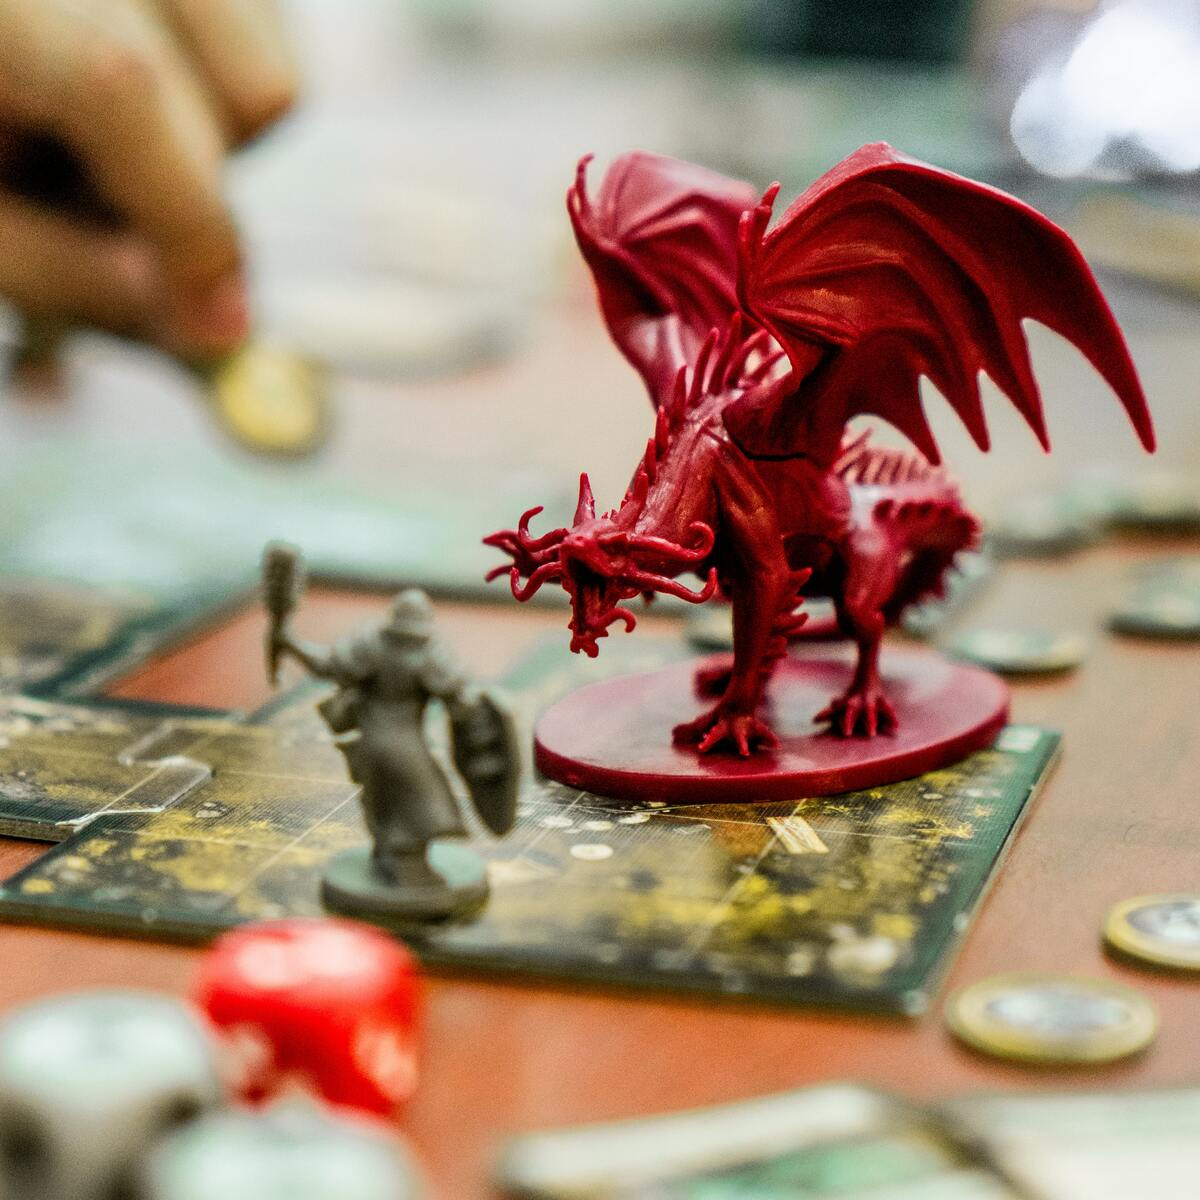

In [130]:
from IPython.display import Image
Image(filename=r"D:\לימודים\HIT\עבודות ונהונות\מדע נתונים\mission3\Monster_picture.jpg",width=400)

In [131]:
import pandas as pd
file_path = r"D:\לימודים\HIT\עבודות ונהונות\מדע נתונים\mission3\updated_dnd_monsters.csv"
df=pd.read_csv(file_path, index_col=0)

categorical_cols = ['type', 'size', 'align', 'source']
df[categorical_cols] = df[categorical_cols].astype('category')
bool_cols=['legendary','fly_speed','swim_speed']
df[bool_cols] = df[bool_cols].astype(bool)
df['release_date'] = pd.to_datetime(df['release_date'], format='%d/%m/%Y')

df.head()

,url,cr,type,size,ac,hp,align,legendary,source,release_date,str,dex,con,int,wis,cha,fly_speed,swim_speed
name,,,,,,,,,,,,,,,,,,
aarakocra,https://www.aidedd.org/dnd/monstres.php?vo=aar...,0.25,humanoid (aarakocra),Medium,12,13,neutral good,False,Monster Manual (BR),2014-07-03,10.0,14.0,10.0,11.0,12.0,11.0,True,False
abjurer,NaN,9.00,humanoid (any race),Medium,12,84,any alignment,False,Volo's Guide to Monsters,2016-11-15,9.0,14.0,14.0,18.0,12.0,11.0,False,False
aboleth,https://www.aidedd.org/dnd/monstres.php?vo=abo...,10.00,aberration,Large,17,135,lawful evil,True,Monster Manual (SRD),2016-01-12,21.0,9.0,15.0,18.0,15.0,18.0,False,True
abominable-yeti,NaN,9.00,monstrosity,Huge,15,137,chaotic evil,False,Monster Manual,2014-09-30,24.0,10.0,22.0,9.0,13.0,9.0,False,False
acererak,NaN,23.00,undead,Medium,21,285,neutral evil,False,Adventures (Tomb of Annihilation),2017-09-19,13.0,16.0,20.0,27.0,21.0,20.0,False,False


## 2. Meta-Analysis

### 2.1 File Analysis

* **File Format:** CSV 
* **File Size:**

In [132]:
import os
os.path.getsize(file_path) / 1024

112.9208984375

* **Creation Date:** 2020
* **Purpose of the Data:** The data serves as a digitized compendium of monster statistics. Its primary purpose is to provide structured information for running the game smoothly, allowing players and Dungeon Masters to quickly reference combat stats like HP, AC, and CR without manually searching through physical books.

### 2.2 Data Structure

In [133]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}\n")

df.info()

Number of Rows: 762
Number of Columns: 18

<class 'pandas.DataFrame'>
Index: 762 entries, aarakocra to zuggtmoy
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   url           401 non-null    str           
 1   cr            762 non-null    float64       
 2   type          762 non-null    category      
 3   size          762 non-null    category      
 4   ac            762 non-null    int64         
 5   hp            762 non-null    int64         
 6   align         762 non-null    category      
 7   legendary     762 non-null    bool          
 8   source        762 non-null    category      
 9   release_date  753 non-null    datetime64[us]
 10  str           762 non-null    float64       
 11  dex           762 non-null    float64       
 12  con           762 non-null    float64       
 13  int           762 non-null    float64       
 14  wis           762 non-null    float64       
 15  

* **Rows and Columns:** 762 rows × 18 columns
* **Data Dictionary:**
    * **name:** The name of the monster (String - Index).
    * **url:** A web link to the monster's detailed profile on aidedd.org (String).
    * **cr:** Challenge Rating, representing the intended difficulty level of the monster (Numerical - Float64).
    * **type:** The creature's classification (Categorical - e.g, humanoid, aberration, monstrosity).
    * **size:** The physical size category of the monster (Categorical - e.g, Medium, Large, Huge).
    * **ac:** Armor Class, determining how difficult it is to physically hit the monster in combat (Numerical - int64).
    * **hp:** Hit Points, representing the monster's total health pool (Numerical - int64).
    * **align:** The creature's moral and ethical alignment (Categorical - e.g, lawful evil, neutral good, unaligned).
    * **legendary:** Indicates if the monster is a legendary creature with special actions (Bool: 0 = No, 1 = Yes).
    * **source:** The specific D&D rulebook or supplement where the monster was published (Categorical - e.g, Monster Manual,Volo's Guide to Monsters).
    * **release_date:** The original publication date of the source material (datetime64).
    * **str, dex, con, int, wis, cha:** The core ability scores (Strength, Dexterity, Constitution, Intelligence, Wisdom, and Charisma) determining the creature's physical and mental capabilities (Numerical - Float64).
    * **fly_speed, swim_speed:** The movement capabilities of the creature (Bool: 0=No, 1=Yes).

* **Operation & Biases:**  
The data was collected for operational purposes rather than scientific research. It is a functional dataset designed to operate virtual tabletops and assist in encounter building. 
Because of this operational nature, several biases might exist:
    * **Source Bias:** The dataset might be heavily skewed towards free rules (SRD) or the core Monster Manual, potentially underrepresenting monsters from newer or obscure expansion books.
    * **Game-Balance Bias:** The stats are artificially constructed to provide a balanced challenge for players, meaning the data does not represent a natural, simulated ecology, but rather a curated set of mechanical obstacles.

## 3. Data Quality and Completeness

### 3.1 Missing Data

#### Extent of Missing Data:

In [134]:
df.isnull().sum()

url             361
cr                0
type              0
size              0
ac                0
hp                0
align             0
legendary         0
source            0
release_date      9
str               0
dex               0
con               0
int               0
wis               0
cha               0
fly_speed         0
swim_speed        0
dtype: int64

Based on our analysis, the dataset is missing data in several specific columns:  
    **- url:** Missing 361 values.  
    **- release_date:** Missing 9 values.

#### Pattern:

In [135]:
missing_dates_df = df[df['release_date'].isnull()]

# Display the value counts of the 'source' column for these specific rows
source_counts = missing_dates_df['source'].value_counts()
print("Sources for monsters with missing release dates:")
print(source_counts[source_counts > 0])

Sources for monsters with missing release dates:
source
Extra (AideDD)                5
Extra (Adventurers League)    3
Extra (Dragon Mag)            1
Name: count, dtype: int64


There are exactly 9 missing values in the release_date column. By examining the source of these specific monsters, a clear pattern emerges: all of them originate from non-core or supplementary materials categorized as "Extra".

#### What can be inferred from the missing data?

The missing release_date values are entirely isolated to monsters originating from "Extra" sources. 
Unlike official rulebooks (e.g., *Monster Manual*) which have globally standardized and well-documented publication dates, these supplementary materials often lack a formal release date.

#### How to fill in the missing data?

**The `URL` Column (361 missing):**
Since a URL is a unique identifier and holds no statistical value for numerical analysis, we cannot impute it.  

**The Release Date (`release_date` - 9 missing):**
Since these 9 missing values constitute a negligible portion of the dataset, leaving them as missing is acceptable and will not impact the overall analysis.

### 3.2 Duplicates

#### Full Duplicates:

In [136]:
full_dupes = df.reset_index().duplicated().sum()
print(f"Total full duplicates: {full_dupes}")

Total full duplicates: 0


There are 0 full duplicates in the dataset. No single row is a perfect copy of another.

#### Partial Duplicates:

In [137]:
# Check for Partial Duplicates based on the unique identifier (Index)
partial_dupes_name = df.index.duplicated().sum()
print(f"Total partial duplicates (by Name): {partial_dupes_name}")

# Check for Partial Duplicates based on identical combat statistics
stats_cols = ['cr', 'type', 'size', 'ac', 'hp', 'align']
stats_dupes = df.duplicated(subset=stats_cols).sum()
print(f"Monsters with identical combat stats: {stats_dupes}")

Total partial duplicates (by Name): 0
Monsters with identical combat stats: 36


**By Unique Identifier:** The monster's name serves as unique index.  
**By Mechanical Stats:** We checked for partial duplicates based purely on combat statistics (ignoring names and URLs). Here, we found 36 matches.

#### What can be inferred from the duplicates?

Having 0 full duplicates shows that the data collection was clean. The partial duplicates (monsters sharing the exact same stats) are not errors. In D&D, completely different creatures often share the same basic combat stats (like HP and AC) because they differ in special attacks and abilities, which are not included in this dataset.

### 3.3 Suspicious Values

In [138]:
# Select all numerical columns for suspicious value checking
numeric_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']

# Create a dictionary to hold the results of our checks
suspicious_checks = {}

for col in numeric_cols:
    suspicious_checks[col] = {
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Zeros': (df[col] == 0).sum(),
        'Negatives': (df[col] < 0).sum(),
        '999s (Placeholder)': (df[col] == 999).sum()
    }

# Convert to DataFrame for a clean display
suspicious_df = pd.DataFrame(suspicious_checks).T
print(suspicious_df)

     Min    Max  Zeros  Negatives  999s (Placeholder)
cr   0.0   30.0   56.0        0.0                 0.0
ac   5.0   25.0    0.0        0.0                 0.0
hp   1.0  676.0    0.0        0.0                 0.0
str  1.0   30.0    0.0        0.0                 0.0
dex  1.0   28.0    0.0        0.0                 0.0
con  3.0   30.0    0.0        0.0                 0.0
int  1.0   27.0    0.0        0.0                 0.0
wis  1.0   27.0    0.0        0.0                 0.0
cha  1.0   30.0    0.0        0.0                 0.0


By running statistical checks on all numeric columns, we analyzed the data for impossible values, placeholders, and unreasonable zeros or negative numbers.

* **Impossible Values & Placeholders:**  
  There are **0** negative values and **0** typical placeholder values (e.g., 999 or -1) in the dataset. Furthermore, the maximum value for any core ability score (`str`, `dex`, `con`, `int`, `wis`, `cha`) is exactly 30, and the minimum is 1. In D&D 5e mechanics, ability scores are strictly bound between 1 and 30. Hit Points (`hp`) and Armor Class (`ac`) also fall within perfectly normal physical boundaries for the game (Minimum HP is 1, meaning no dead monsters are listed).

* **Unreasonable Zeros:**   
  The only column containing zeros is `cr` (Challenge Rating), which has exactly 56 zeros. In Dungeons & Dragons a CR of 0 is a mathematically valid game mechanic representing harmless creatures (e.g., a cat, bat, or baboon). Therefore, these are completely reasonable zeros.

* **What do these values tell us about the data?**  
  It indicates that this dataset was not manually entered by users (which is prone to human error), but rather programmatically scraped from a rule-bound database.

### 3.4 Cardinality

* **Columns with no variance (Single Value):**  

In [139]:
# Calculate the number of unique values for each column
cardinality = df.nunique().sort_values()


# Identify if there are any columns with zero variance (only 1 unique value)
single_value_cols = cardinality[cardinality == 1]
print(f"\nColumns with exactly 1 unique value: {len(single_value_cols)}")


Columns with exactly 1 unique value: 0


  There are no columns in this dataset with exactly one unique value. Every feature provides at least some mathematical or categorical variance, meaning no columns need to be dropped due to zero variance.

* **Columns with high cardinality:**

In [140]:
print("--- Cardinality (Number of Unique Values) Per Column ---")
print(cardinality)

--- Cardinality (Number of Unique Values) Per Column ---
legendary         2
fly_speed         2
swim_speed        2
size              6
release_date     14
align            15
source           17
ac               20
con              24
dex              24
wis              26
int              27
cha              29
str              30
cr               31
type             71
hp              159
url             401
dtype: int64


Working with high-cardinality categorical variables introduces "noise" and dilutes statistical significance. To extract meaningful insights, we first aggregated small and highly fragmented groups into broader, more significant parent categories:
*   `align`: Grouped into 4 core moral categories ('Good', 'Evil', 'Unaligned', 'Neutral').
*   `type`: Stripped of all sub-races by removing everything inside parentheses (e.g., 'humanoid (elf)' became simply 'humanoid').
*   `source`: Combined all minor supplemental magazines into 'Extra', and aggregated all specific campaign books into a single 'Adventures' category.

In [141]:
df = pd.read_csv("updated_dnd_monsters.csv", index_col=0)
df_cleaned = df.copy()

# 1. Type grouping: Remove anything from the '(' onwards and clear whitespace
df_cleaned['type_grouped'] = df_cleaned['type'].str.split('(').str[0].str.strip()

# 2. Align grouping: Exactly 4 categories
def group_align_exact(a):
    if pd.isna(a): return a
    a = str(a).lower()
    if 'unaligned' in a: return 'Unaligned'
    if 'evil' in a: return 'Evil'
    if 'good' in a: return 'Good'
    return 'Neutral' # Catch-all for neutral and 'any' alignments

df_cleaned['align_grouped'] = df_cleaned['align'].apply(group_align_exact)

# 3. Source grouping: Only group the "Extra" books
def group_source_exact(s):
    if pd.isna(s): return s
    s = str(s)
    if 'Extra' in s: return 'Extra'
    if 'Adventures' in s: return 'Adventures'
    return s

df_cleaned['source_grouped'] = df_cleaned['source'].apply(group_source_exact)

df_cleaned.to_csv("dnd_monsters_cleaned.csv")

# --- PROOF OF EXECUTION ---
print("--- PROOF OF GROUPING ---")

num_align = df_cleaned['align_grouped'].nunique()
num_source = df_cleaned['source_grouped'].nunique()
num_type = df_cleaned['type_grouped'].nunique()

print(f"Number of Align categories: {num_align}")
print(f"Number of Source categories: {num_source}")
print(f"Number of Type categories: {num_type}")

print("\n1. ALIGN:")
print(df_cleaned['align_grouped'].value_counts())

print("\n2. SOURCE:")
print(df_cleaned['source_grouped'].value_counts())

print("\n3. TYPE:")
print(df_cleaned['type_grouped'].value_counts())

--- PROOF OF GROUPING ---
Number of Align categories: 4
Number of Source categories: 8
Number of Type categories: 15

1. ALIGN:
align_grouped
Evil         378
Unaligned    171
Neutral      158
Good          55
Name: count, dtype: int64

2. SOURCE:
source_grouped
Monster Manual (SRD)           326
Mordenkainen's Tome of Foes    133
Volo's Guide to Monsters       117
Monster Manual                  65
Adventures                      51
Monster Manual (BR)             37
Essentials Kit                  24
Extra                            9
Name: count, dtype: int64

3. TYPE:
type_grouped
humanoid                189
beast                   106
fiend                    89
monstrosity              86
undead                   50
dragon                   47
elemental                38
aberration               37
giant                    27
construct                24
plant                    24
fey                      21
ooze                      8
celestial                 8
swarm of Tiny be

## 4. Univariate Analysis

Feature  Mean  Median   Std   MAD  Min   Max   Q1    Q3   IQR  Skewness  Outliers (IQR)  Outliers (Z-score)  Outliers (MAD)
     cr  5.55     3.0  6.25  2.75  0.0  30.0  0.5   9.0   8.5      1.40              25                   6             128
     ac 14.60    14.0  3.10  2.00  5.0  25.0 12.0  17.0   5.0      0.22               2                   6              32
     hp 88.19    58.0 94.78 40.00  1.0 676.0 22.0 126.0 104.0      2.26              38                  14             102
    str 15.01    15.0  6.14  4.00  1.0  30.0 11.0  19.0   8.0      0.05               0                   0              47
    dex 13.30    14.0  3.42  2.00  1.0  28.0 11.0  15.0   4.0      0.12              20                  14              42
    con 15.33    15.0  4.30  3.00  3.0  30.0 12.0  18.0   6.0      0.86              10                   8              34
    int  9.66    10.0  5.87  4.00  1.0  27.0  5.0  14.0   9.0      0.32               0                   0              13
    wis 

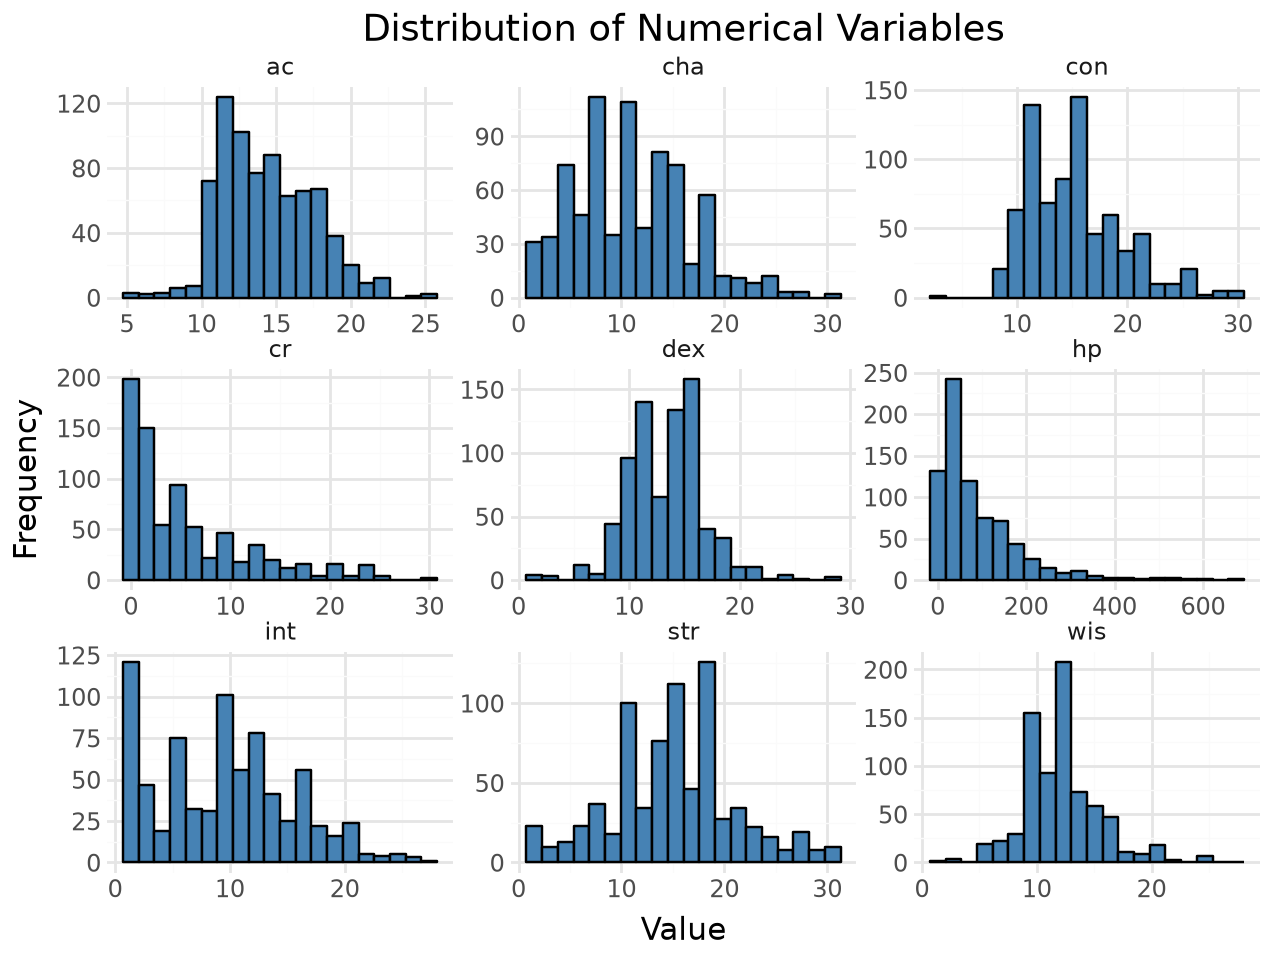

In [142]:
import numpy as np
import plotnine as pln

# Select numerical columns
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_num = df[num_cols].dropna()

# 1. Descriptive Statistics & Outliers
stats_dict = []
for col in num_cols:
    data = df_num[col]
    mean = data.mean()
    median = data.median()
    std = data.std()
    min_v = data.min()
    max_v = data.max()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    mad = (data - median).abs().median()
    skew = data.skew()
    
    # Outliers calculation using 3 methods
    outliers_iqr = ((data < (q1 - 1.5 * iqr)) | (data > (q3 + 1.5 * iqr))).sum()
    outliers_z = (np.abs((data - mean) / std) > 3).sum()
    outliers_mad = (np.abs(data - median) / mad > 3).sum() if mad != 0 else (np.abs(data - median) > 0).sum()
    
    stats_dict.append({'Feature': col, 'Mean': round(mean,2), 'Median': median, 'Std': round(std,2), 
                       'MAD': mad, 'Min': min_v, 'Max': max_v, 'Q1': q1, 'Q3': q3, 'IQR': iqr, 
                       'Skewness': round(skew,2), 'Outliers (IQR)': outliers_iqr, 
                       'Outliers (Z-score)': outliers_z, 'Outliers (MAD)': outliers_mad})

stats_df = pd.DataFrame(stats_dict)
print(stats_df.to_string(index=False))

# 2. Visualizing Distributions with plotnine
df_melted = df_num.melt(var_name='Feature', value_name='Value')

hist_plot = (
    pln.ggplot(df_melted, pln.aes(x='Value')) +
    pln.geom_histogram(bins=20, fill='steelblue', color='black') +
    pln.facet_wrap('~Feature', scales='free') +
    pln.theme_minimal() +
    pln.labs(title="Distribution of Numerical Variables", x="Value", y="Frequency")
)
hist_plot

* **Distribution, Skewness & Bias:**  
  * **Right-Skewed (Biased) Variables:** The data is heavily biased towards lower values in variables like `hp` (Hit Points) and `cr` (Challenge Rating). The histograms show a massive peak on the left and a long tail extending to the right. This is confirmed by their high positive skewness values (2.26 for `hp` and 1.40 for `cr`). Because of these extreme high values (the "boss" monsters), the mean is pulled significantly higher than the median. For example, the mean `hp` is 88.19, but the median is only 58.0.  
  * **Symmetric Variables:** Attributes like `str` and `dex` are much more symmetric and lack a prominent tail. `str` has a skewness of 0.05 and `dex` is almost perfectly balanced at 0.12. Their histograms resemble a more normal, bell-shaped distribution (with `str` being slightly flat).

* **Outliers Detection:**  
  * **IQR Method:** Identified a moderate number of outliers, primarily catching the extreme high values in the right-skewed variables (e.g., 25 outliers for `cr` and 38 for `hp`). It found 0 outliers for `str`, which aligns with its symmetric distribution.
  * **Z-Score Method (Threshold = 3):** Detected the fewest outliers across all features (e.g., only 14 for `hp` and 6 for `cr`). Because the Z-score calculation relies on the mean and standard deviation—both of which are already inflated by the extreme high values in our skewed data—the "normal" range is stretched too far, causing it to miss many genuine outliers.
  * **MAD Method:** Detected the highest number of outliers by far (e.g., 128 for `cr`, 102 for `hp`, and 47 for `str`). Because MAD is based on the median, it is highly robust and ignores extreme values when defining the "center" of the data. This creates a much tighter boundary for what is considered normal, flagging many higher-tier monsters as mathematical outliers compared to the typical baseline.

## 5. Correlations and Relationships

### 5.1 Numerical-Numerical Correlations

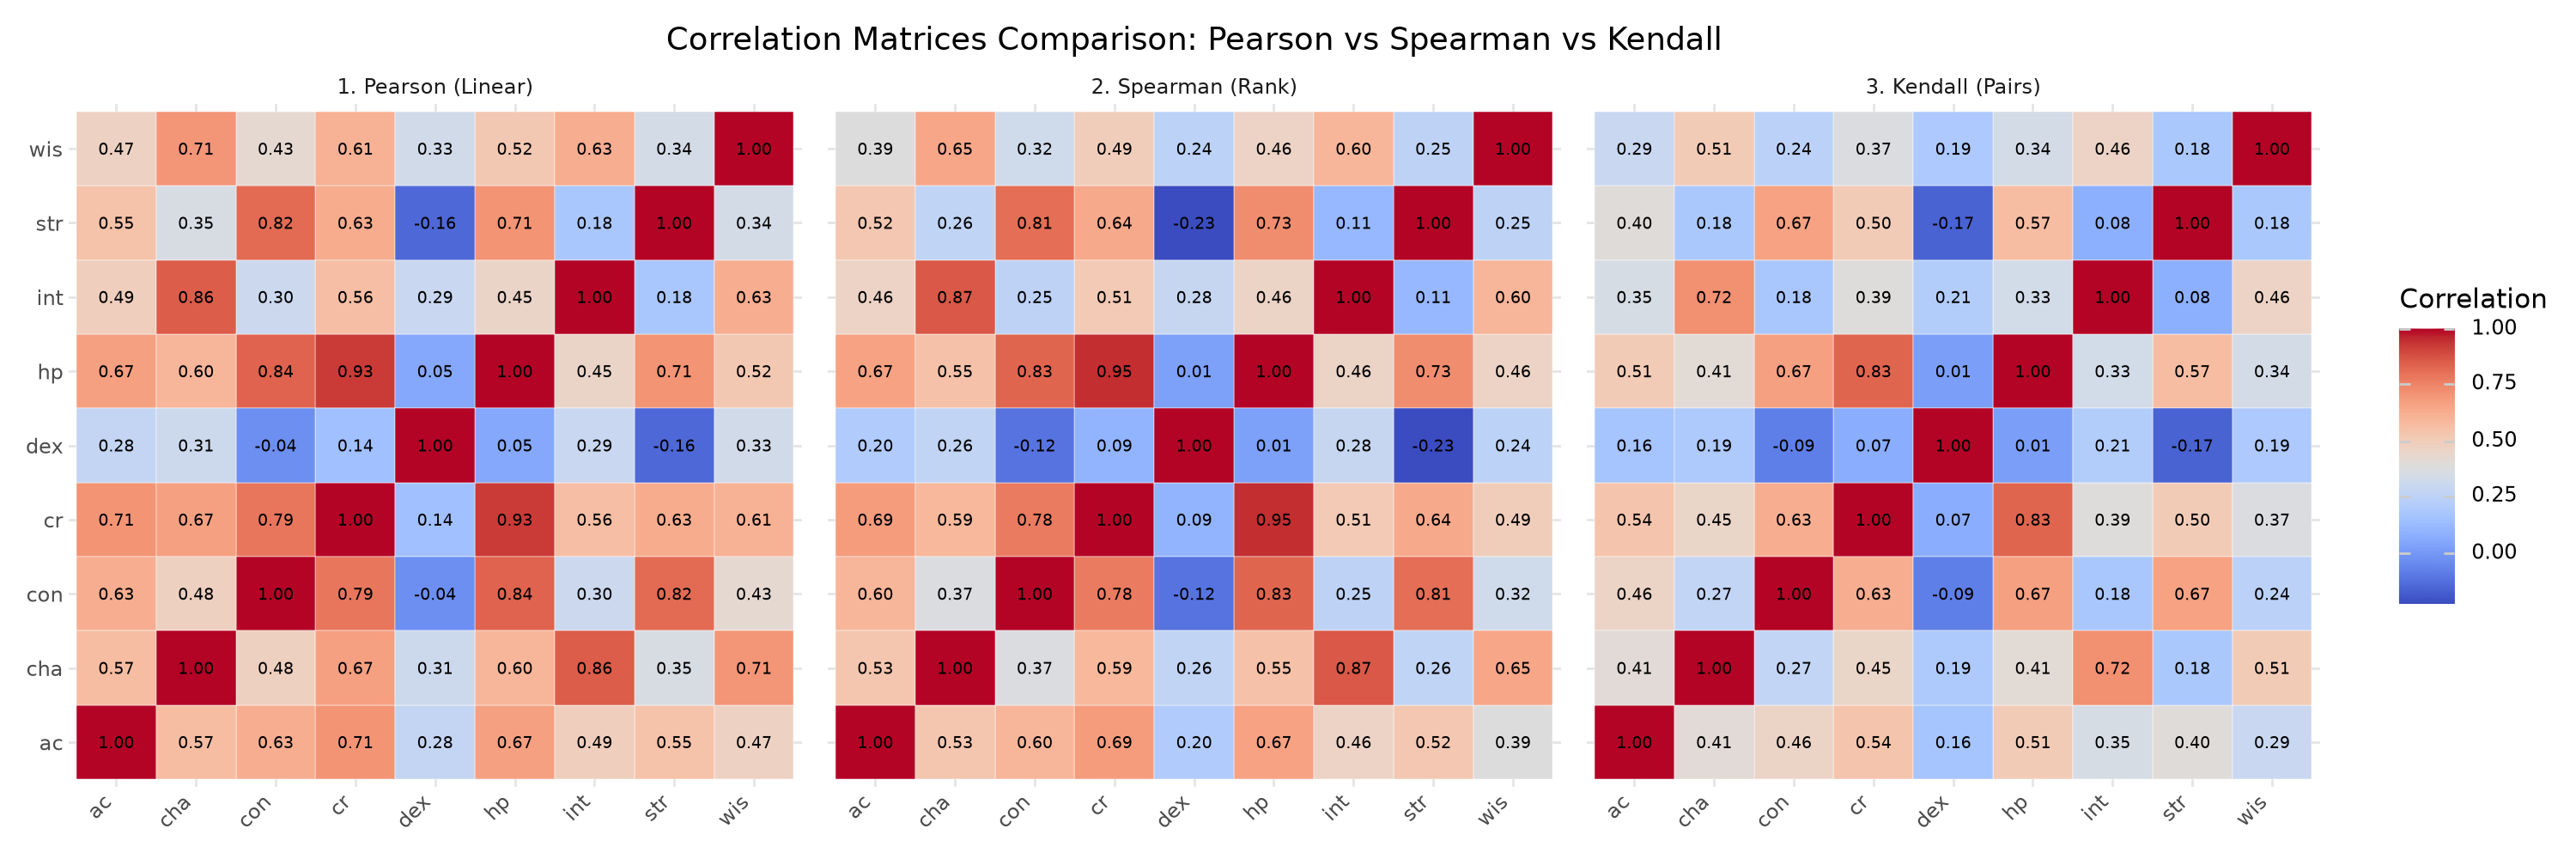

In [143]:
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_num = df[num_cols].dropna()

# 1. Calculate the 3 correlation matrices
pearson_corr = df_num.corr(method='pearson')
spearman_corr = df_num.corr(method='spearman')
kendall_corr = df_num.corr(method='kendall')

# 2. Melt and label each matrix for plotnine
p_melt = pearson_corr.reset_index().melt(id_vars='index')
p_melt['Method'] = '1. Pearson (Linear)'

s_melt = spearman_corr.reset_index().melt(id_vars='index')
s_melt['Method'] = '2. Spearman (Rank)'

k_melt = kendall_corr.reset_index().melt(id_vars='index')
k_melt['Method'] = '3. Kendall (Pairs)'

# Combine all into one DataFrame
combined_corr = pd.concat([p_melt, s_melt, k_melt])
combined_corr.columns = ['Var1', 'Var2', 'Correlation', 'Method']

# 3. Plot all 3 heatmaps side-by-side using facet_wrap
heatmap_all = (
    pln.ggplot(combined_corr, pln.aes(x='Var1', y='Var2', fill='Correlation')) +
    pln.geom_tile(color='white') +
    pln.geom_text(pln.aes(label='Correlation'), format_string='{:.2f}', size=7) +
    pln.scale_fill_cmap(cmap_name='coolwarm') +
    pln.facet_wrap('~Method', ncol=3) +
    pln.theme_minimal() +
    pln.theme(axis_text_x=pln.element_text(rotation=45, hjust=1), figure_size=(15, 5)) +
    pln.labs(title="Correlation Matrices Comparison: Pearson vs Spearman vs Kendall", x="", y="")
)
display(heatmap_all)

By visualizing all three correlation matrices side-by-side, we can observe the impact of our data's distribution on the results:
*   **Spearman yields the highest scores (e.g., 0.97 for `cr` vs `hp`):** This happens because Spearman evaluates the *rank* of the monsters rather than their raw numbers. Since our data features exponential scaling (HP jumps massively at higher CRs) and extreme outliers (boss monsters), Spearman ignores these mathematical distortions and perfectly captures the underlying monotonic upward trend.
*   **Pearson yields slightly lower scores (e.g., 0.94 for `cr` vs `hp`):** Pearson searches for a strict, straight linear line. Because our high-level monsters pull the data upward into a curve and create extreme outliers, Pearson's linear line is skewed, resulting in a penalized, lower correlation score.
*   **Kendall yields the lowest scores across the entire heatmap (e.g., 0.87 for `cr` vs `hp`):** Kendall calculates correlation by looking at pairs of data. It mathematically produces lower coefficients when there are many identical values. Since D&D monsters frequently share the exact same base stats (e.g., dozens of monsters have exactly 10 `str` or 13 `ac`), Kendall's score is naturally suppressed across our entire dataset.

--- Correlation between CR and HP ---
Pearson (Linear):   0.926
Spearman (Rank):    0.951
Kendall (Pairs):    0.835



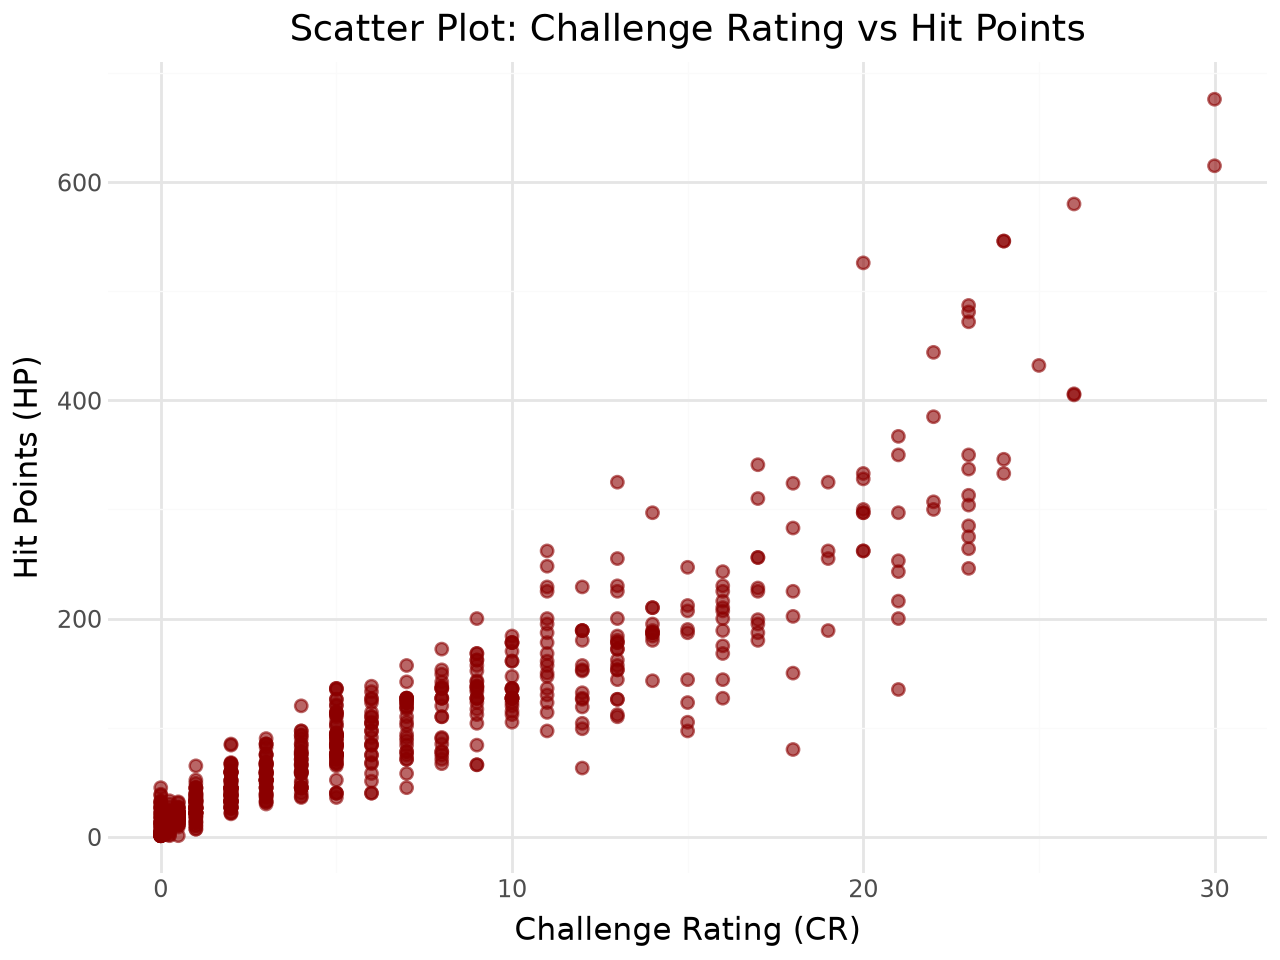

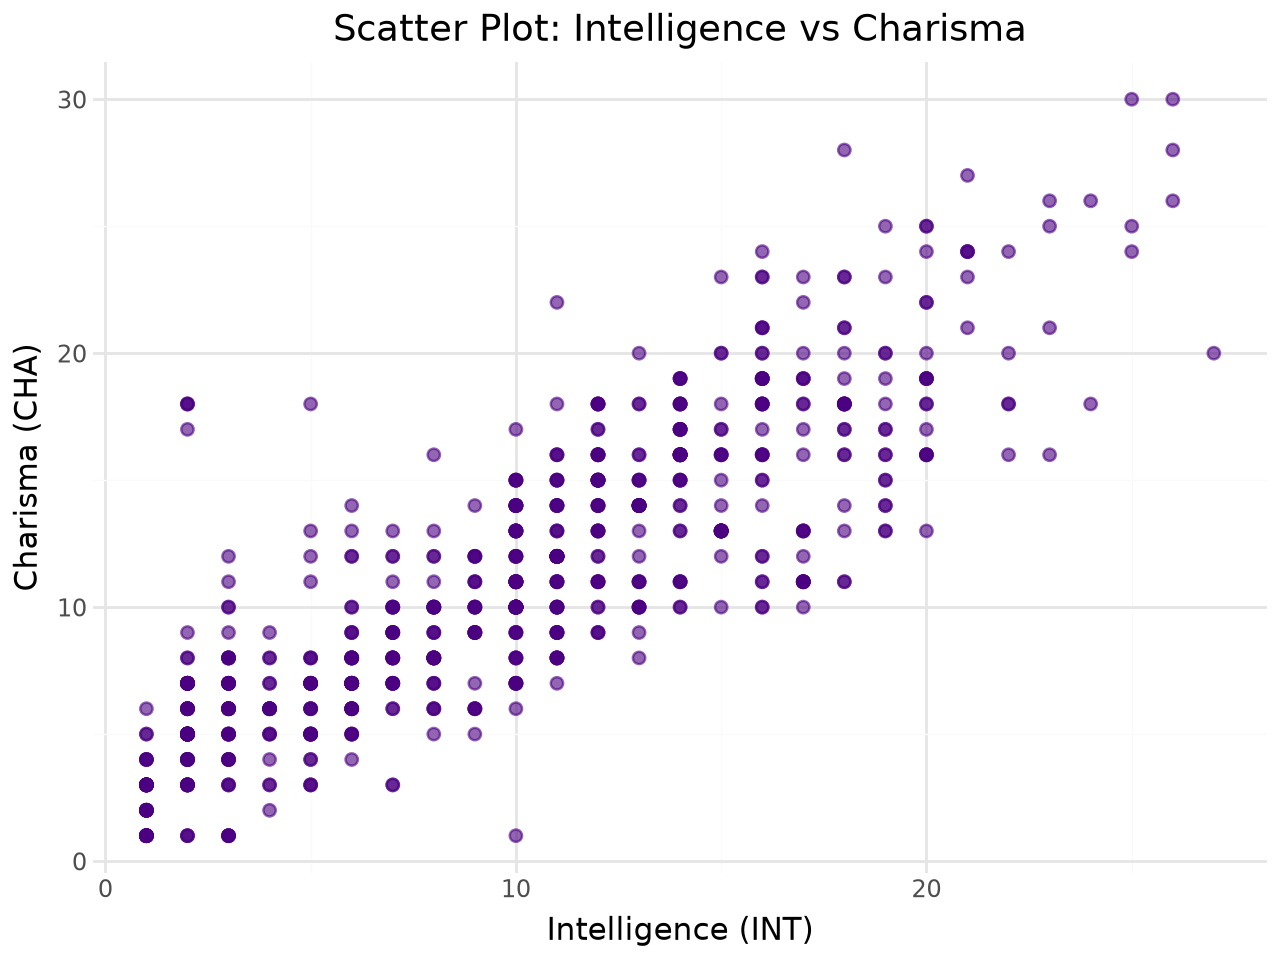

In [144]:
# Print comparison of the strongest connection (CR vs HP) across all 3 methods
print("--- Correlation between CR and HP ---")
print(f"Pearson (Linear):   {pearson_corr.loc['cr', 'hp']:.3f}")
print(f"Spearman (Rank):    {spearman_corr.loc['cr', 'hp']:.3f}")
print(f"Kendall (Pairs):    {kendall_corr.loc['cr', 'hp']:.3f}\n")

# Scatter Plot: CR vs HP
scatter_cr_hp = (
    pln.ggplot(df_num, pln.aes(x='cr', y='hp')) +
    pln.geom_point(color='darkred', alpha=0.6, size=2) +
    pln.theme_minimal() +
    pln.labs(title="Scatter Plot: Challenge Rating vs Hit Points", x="Challenge Rating (CR)", y="Hit Points (HP)")
)
display(scatter_cr_hp)

# Scatter Plot: INT vs CHA
scatter_int_cha = (
    pln.ggplot(df_num, pln.aes(x='int', y='cha')) +
    pln.geom_point(color='indigo', alpha=0.6, size=2) +
    pln.theme_minimal() +
    pln.labs(title="Scatter Plot: Intelligence vs Charisma", x="Intelligence (INT)", y="Charisma (CHA)")
)
display(scatter_int_cha)

*   **Challenge Rating (CR) vs. Hit Points (HP):** The scatter plot reveals a strong, positive, upward-curving trend. As CR increases, HP scales up rapidly. Because this relationship curves upwards (exponential growth) rather than following a strict straight line, we can visually understand exactly why Spearman's rank-based method (0.951) scored higher than Pearson's linear method (0.926).

*   **Intelligence (INT) vs. Charisma (CHA):** The graph shows a clear diagonal grouping. There is a dense cluster at the bottom-left representing mindless creatures (like beasts or constructs with minimal INT and CHA), while highly sentient and magical creatures stretch towards the top-right.

**Conclusions on Correlations:** The data reveals distinct mechanical groupings. Combat-defining statistics (cr, hp, con) are highly and positively correlated, as they mathematically dictate a monster's survivability and threat level. Mental attributes (int, cha) also scale together, clearly separating sentient creatures from basic beasts. Conversely, physical agility (dex) shows very weak correlations with almost all other stats, indicating that a monster's speed or reflexes are entirely independent of its size, health pool, or intelligence.

### 5.2 Graphs and Visualizations

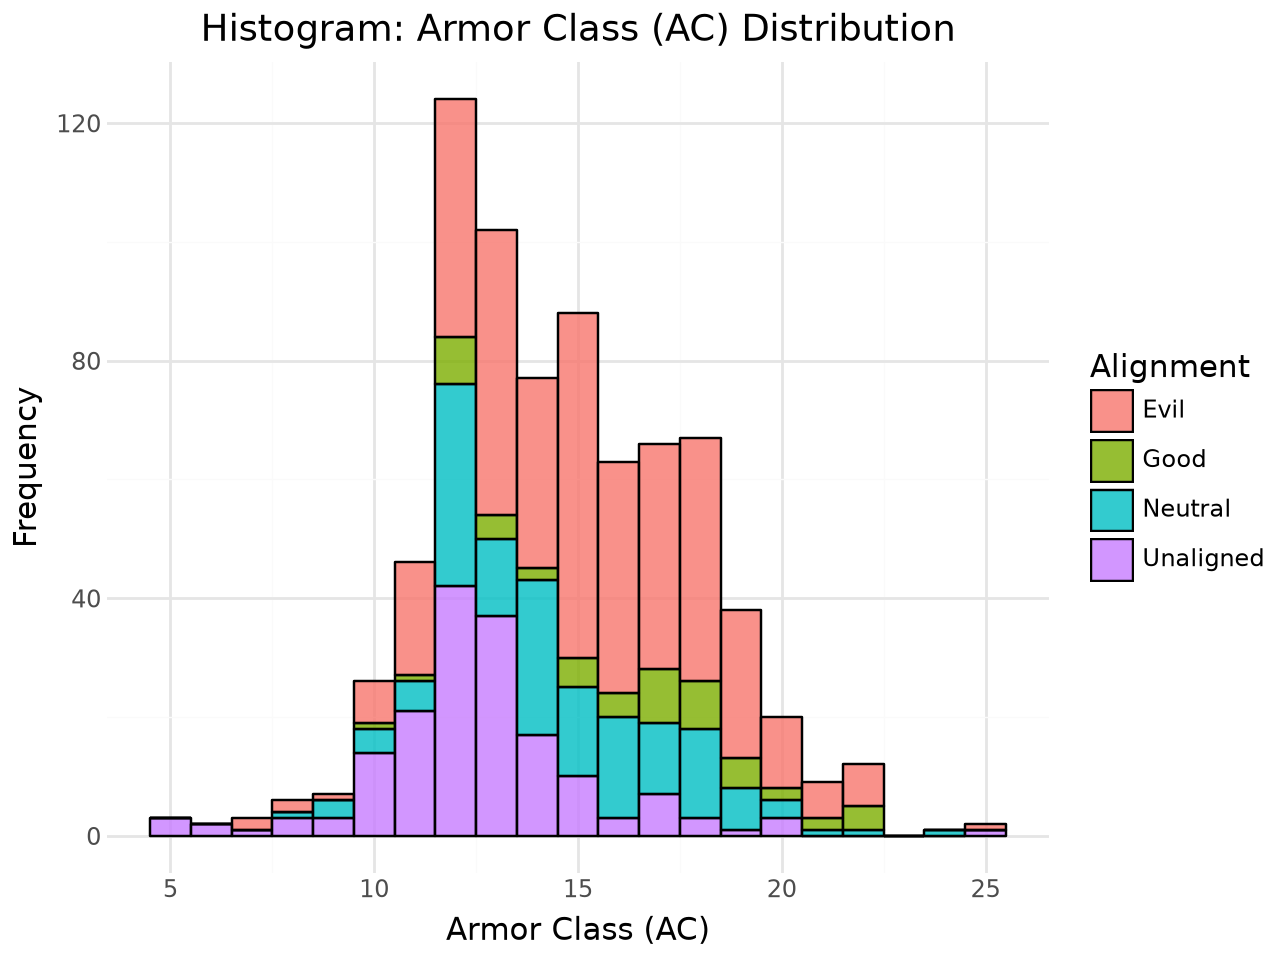

In [145]:
# Histogram: AC Distribution by Grouped Alignment
hist = (pln.ggplot(df_cleaned.dropna(subset=['ac', 'align_grouped']), pln.aes(x='ac', fill='align_grouped')) + 
        pln.geom_histogram(binwidth=1, color='black', alpha=0.8) + 
        pln.theme_minimal() + 
        pln.labs(title="Histogram: Armor Class (AC) Distribution", x="Armor Class (AC)", y="Frequency", fill="Alignment"))
display(hist)

The histogram displays the distribution of Armor Class (AC) across the dataset, revealing a curve that peaks sharply at AC 12 and 13. By color-coding the stacked bars according to our grouped alignments, distinct mechanical patterns clearly emerge:  
*   **The "Unaligned" Base (Low AC):** The "Unaligned" category (purple) makes up a massive portion of the lower AC values (between 10 and 13). This aligns perfectly with game logic, as unaligned creatures are mostly common beasts or animals relying on thick hide rather than forged armor or magic.  
*   **The "Evil" Scaling (Mid to High AC):** As the Armor Class increases beyond 14, the "Unaligned" creatures almost vanish, and the "Evil" category (salmon/red) becomes overwhelmingly dominant. High AC represents heavily armored or magically protected antagonists, which are predominantly evil villains designed for challenging, late-game combat encounters.  
*   **The Rarity of "Good":** "Good" aligned creatures (green) remain statistically rare across the board, appearing in small slivers mostly in the higher AC ranges (15-20), representing powerful but uncommon allies like celestials.

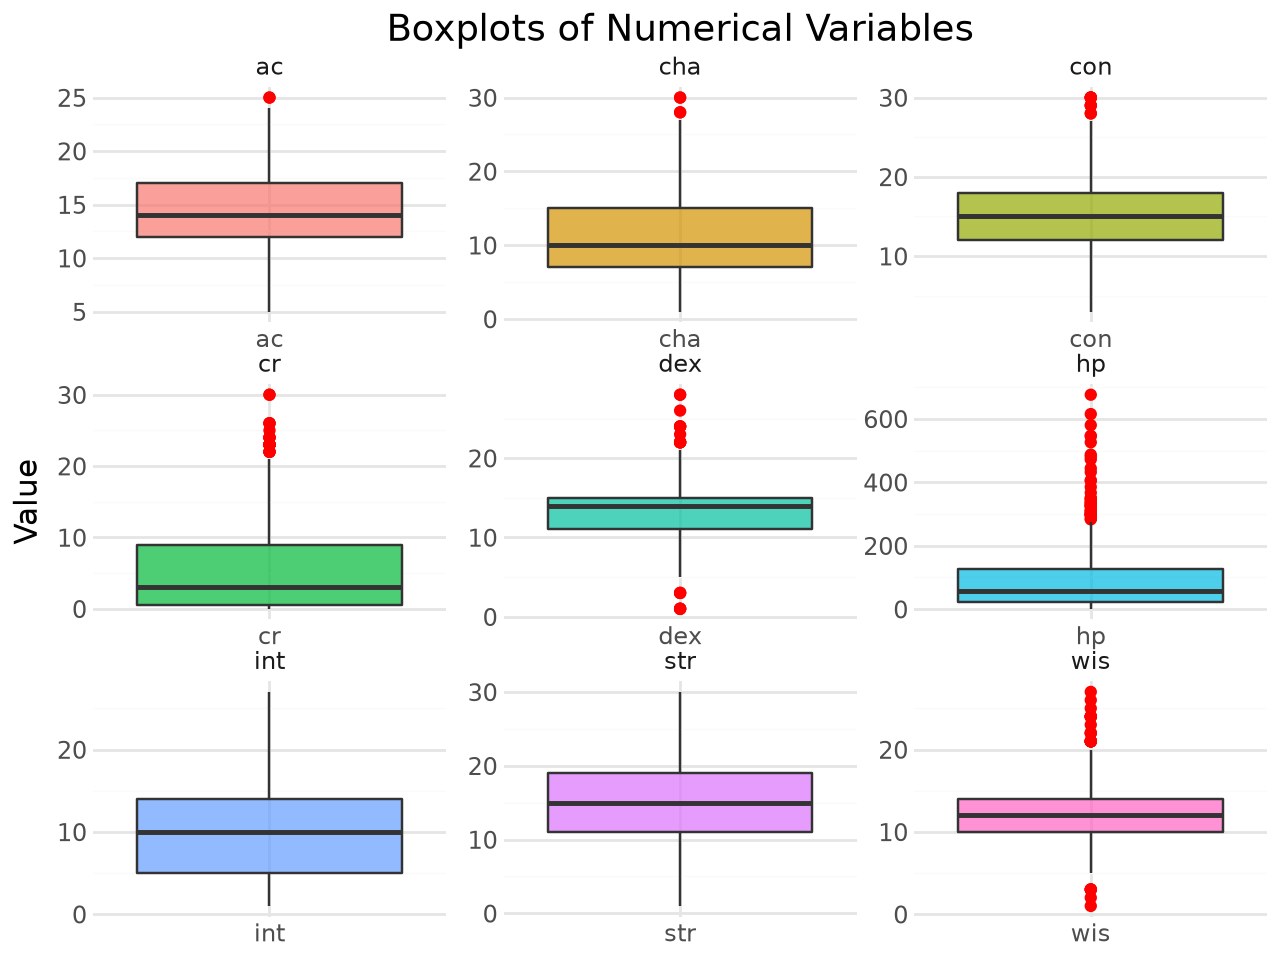

In [146]:
boxplot_plot = (
    pln.ggplot(df_melted, pln.aes(x='Feature', y='Value', fill='Feature')) +
    pln.geom_boxplot(alpha=0.7, outlier_color='red') +
    pln.facet_wrap('~Feature', scales='free') +
    pln.theme_minimal() +
    pln.theme(legend_position='none') +
    pln.labs(title="Boxplots of Numerical Variables", x="", y="Value")
)
display(boxplot_plot)

We can observe that `hp` has a massive number of points beyond the upper whisker, and features like `cr`, `dex`, and `wis` also display multiple outliers. This confirms the presence of exceptionally powerful or highly specialized monsters compared to the median baseline. Conversely, features like `str` and `int` have absolutely no outliers, and `ac` has only a single one, meaning all or nearly all monsters fall strictly within a standardized range for these specific attributes.

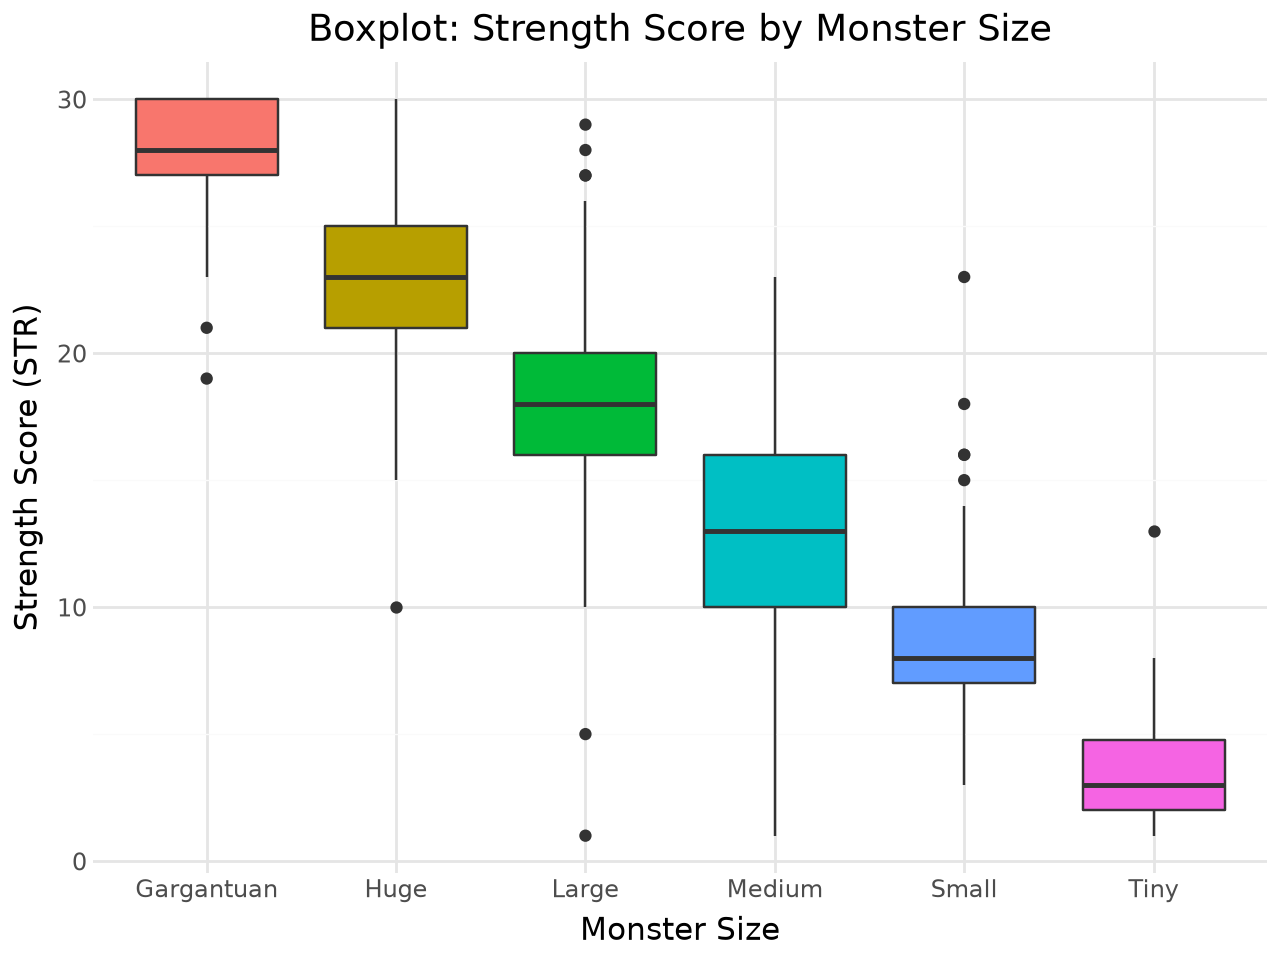

In [147]:
# Boxplot: STR by Size
box = (pln.ggplot(df_cleaned.dropna(subset=['str', 'size']), pln.aes(x='size', y='str', fill='size')) + 
       pln.geom_boxplot(show_legend=False) + 
       pln.theme_minimal() + 
       pln.labs(title="Boxplot: Strength Score by Monster Size", x="Monster Size", y="Strength Score (STR)"))
box

This plot demonstrates a perfect step-function correlation between physical scale and physical power. The median Strength score strictly and consistently increases with size (from a median of 3 for Tiny to 28 for Gargantuan). There is zero interquartile overlap between the extreme sizes, proving that high Strength is biologically hard-coded to massive creatures.

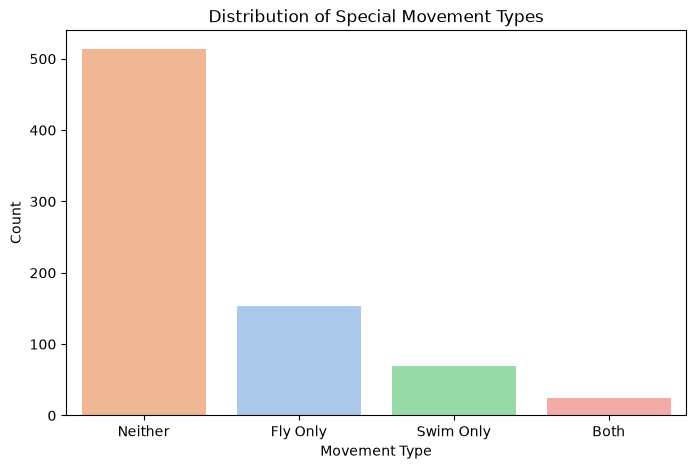

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined Movement Type feature
def get_movement_type(row):
    if row['fly_speed'] > 0 and row['swim_speed'] > 0:
        return 'Both'
    elif row['fly_speed'] > 0:
        return 'Fly Only'
    elif row['swim_speed'] > 0:
        return 'Swim Only'
    else:
        return 'Neither'

df['movement_type'] = df.apply(get_movement_type, axis=1)

# Plot 1: Overall Distribution of Movement Types
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='movement_type', 
    hue='movement_type', # הוספת משתנה הצבע כדי לענות על דרישת הספרייה
    order=['Neither', 'Fly Only', 'Swim Only', 'Both'], 
    palette='pastel',
    legend=False # הסתרת המקרא המיותר שנוצר בגלל ה-hue
)
plt.title('Distribution of Special Movement Types')
plt.ylabel('Count')
plt.xlabel('Movement Type')
plt.show()

A countplot of movement types reveals that the vast majority of D&D monsters (514) rely strictly on standard ground movement ('Neither'). Flight is the most common special mobility (153), while swimming is significantly rarer (70). Creatures possessing absolute mobility—capable of *both* flying and swimming—are exceptionally rare, with only 25 instances in the dataset.

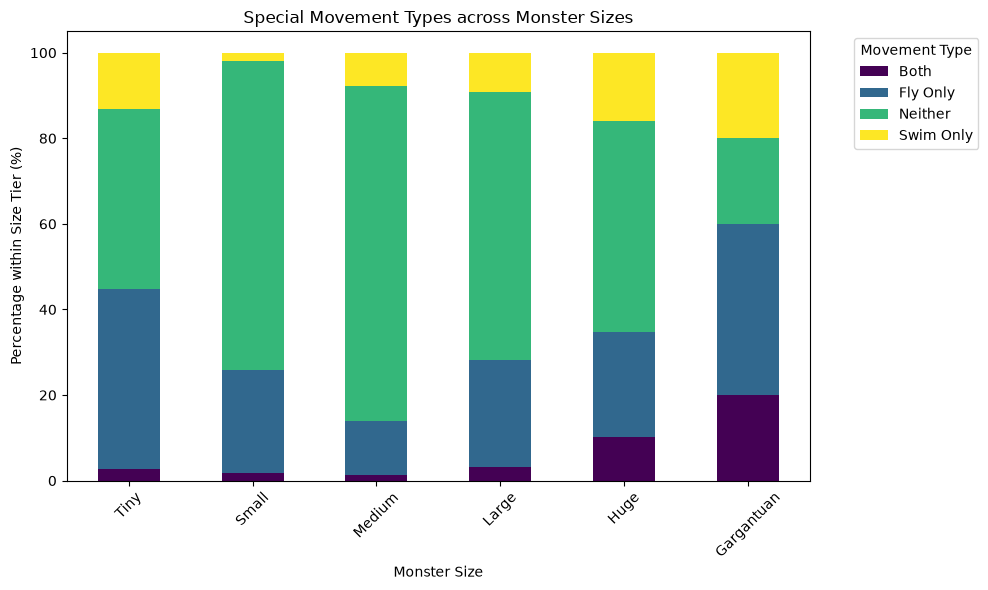

In [149]:
# Plot 2: Movement Type vs Size (100% Stacked Bar)
# ---------------------------------------------------------
size_order = ['Tiny', 'Small', 'Medium', 'Large', 'Huge', 'Gargantuan']
crosstab_size_move = pd.crosstab(df['size'], df['movement_type'], normalize='index') * 100
crosstab_size_move = crosstab_size_move.reindex(size_order)

crosstab_size_move.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Special Movement Types across Monster Sizes')
plt.ylabel('Percentage within Size Tier (%)')
plt.xlabel('Monster Size')
plt.xticks(rotation=45)
plt.legend(title='Movement Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Cross-tabulating movement types with physical size reveals a fascinating game design pattern. Small and Medium creatures are heavily dominated by standard movement ('Neither'). However, "Fly Only" is surprisingly prominent among "Tiny" creatures (nearly 40%), representing familiars, birds, and insects. Conversely, "Swim Only" and "Both" scale aggressively with size; aquatic capability becomes a major defining feature of "Huge" and "Gargantuan" monsters (e.g., Krakens, Leviathans, and Ancient Dragons).

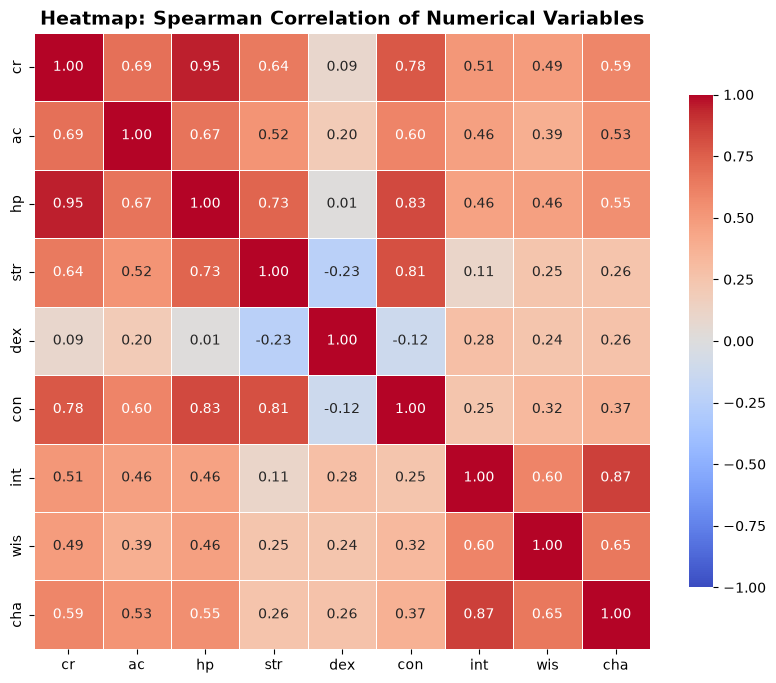

In [150]:
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
corr_matrix = df_cleaned[num_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Heatmap: Spearman Correlation of Numerical Variables", fontsize=14, fontweight='bold')
plt.show()

The heatmap serves as a powerful visual and numerical summary of our dataset, exposing three distinct mechanical clusters and one major outlier:  
*   **The Survival Triangle (`cr`, `hp`, `con`):** The darkest red squares highlight the strongest relationships in the game. Hit Points (`hp`) and Challenge Rating (`cr`) have a near-perfect correlation of **0.95**. Furthermore, Constitution (`con`) is heavily tied to both `hp` (**0.83**) and `cr` (**0.78**). This mathematically confirms that survival stats are the primary metric the game uses to determine a monster's threat level.  
*   **The Physical Brute Cluster (`str`, `con`, `hp`):** Strength (`str`) shows strong positive correlations with `con` (**0.81**) and `hp` (**0.73**). This demonstrates that physically strong monsters are almost exclusively built as massive, high-health bruisers.   
*   **The Sentience Cluster (`int`, `cha`):** There is a massive correlation of **0.87** between Intelligence and Charisma. In game design terms, this sharply divides the dataset between mindless beasts (which dump both stats) and highly sentient or magical creatures (which require high scores in both).    
*   **The Dexterity Outlier (`dex`):** The pale vertical column for `dex` reveals it is completely detached from the typical power scaling. This disconnect occurs because Dexterity serves multiple different mechanical roles depending on the monster's design. Some creatures rely heavily on Dexterity for their defense (Armor Class) and attack accuracy, while others completely bypass it by utilizing massive Hit Point pools, heavy natural armor, or high Strength. Because this single statistic is applied in such diverse and sometimes contradictory ways across different builds, it fails to form a unified, clear statistical pattern across the general dataset.

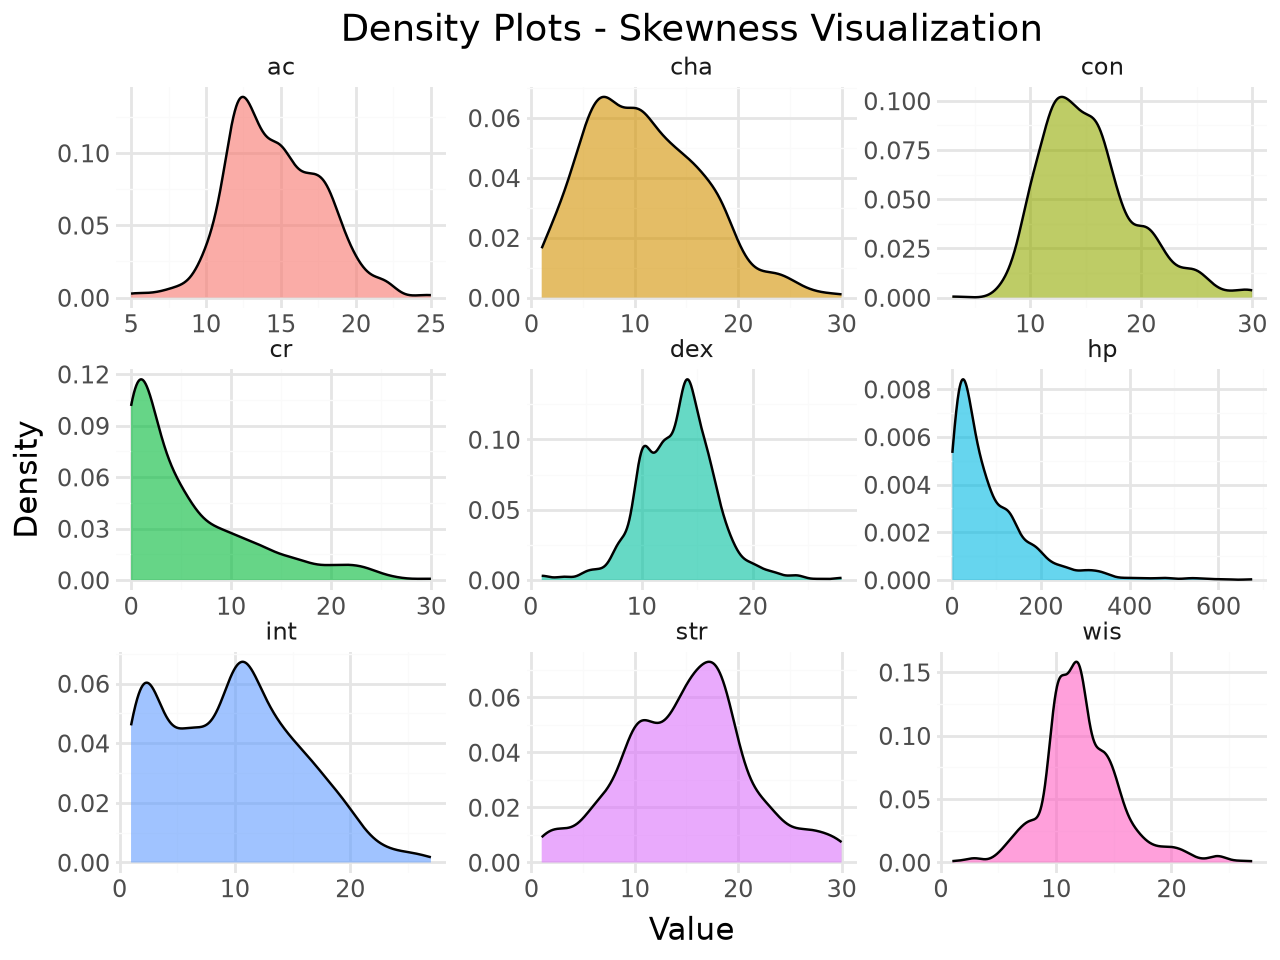

In [151]:
skewness_plot = (
    pln.ggplot(df_melted, pln.aes(x='Value', fill='Feature')) +
    pln.geom_density(alpha=0.6, color='black') +
    pln.facet_wrap('~Feature', scales='free') +
    pln.theme_minimal() +
    pln.theme(legend_position='none') +
    pln.labs(title="Density Plots - Skewness Visualization", x="Value", y="Density")
)
display(skewness_plot)

* **Strong Positive Skewness (Right-Skewed):** Features like `hp` (Hit Points) and `cr` (Challenge Rating) exhibit a very strong right skew. The bulk of the data is concentrated at the lower end (representing standard, weaker monsters), with a long tail extending far to the right. This visually confirms the presence of extreme outliers—the rare, exceptionally powerful "boss" creatures.
* **Symmetric / Normal-like Distributions:** Attributes such as `dex` (Dexterity), `wis` (Wisdom), and `con` (Constitution) show a much more symmetric, bell-shaped curve (low skewness). This indicates that most monsters fall within an average baseline for these stats, with fewer creatures possessing exceptionally low or high values.
* **Bimodal Tendencies:** The `int` (Intelligence) feature displays an interesting, somewhat bimodal distribution. There is a noticeable peak at the very low end (likely representing unintelligent beasts, oozes, or constructs) and a second, wider peak around the average humanoid intelligence (10-12).

In [152]:
kurtosis_df = pd.DataFrame({'Kurtosis': df_num.kurtosis()})
print("--- Kurtosis per Feature ---")
display(kurtosis_df.round(2))

--- Kurtosis per Feature ---


,Kurtosis
cr,1.33
ac,0.09
hp,7.02
str,-0.05
dex,1.83
con,0.70
int,-0.62
wis,2.08
cha,-0.11


The kurtosis values support our previous skewness findings. `hp` shows a very high kurtosis (7.02), indicating a leptokurtic distribution with heavy tails and extreme outliers (representing "boss" monsters with massive hit points). Variables like `str` (-0.05) and `cha` (-0.11) show a flatter, more uniform spread of scores without extreme tails.

* **Possible noise:** Traditional statistical noise (random fluctuations or variance in data collection) does not exist in this dataset. Every stat is a deterministic, deliberately chosen number assigned by game designers to balance gameplay.
* **Measurement artifacts:** Since the data is not gathered by physical sensors or experimental instruments, measurement artifacts are completely irrelevant to this dataset.
* **Data-entry problems:** Human error during the manual transcription from the physical rulebooks to the digital CSV format could cause data-entry problems (e.g., a typo resulting in a Strength score of 300 instead of 30). However, our previous analysis ("Suspicious Values") confirmed that all core ability scores fall strictly within the valid 1-30 range dictated by the game's rules. Therefore, we found no evidence of data-entry errors.

## 6. Dimensionality Reduction

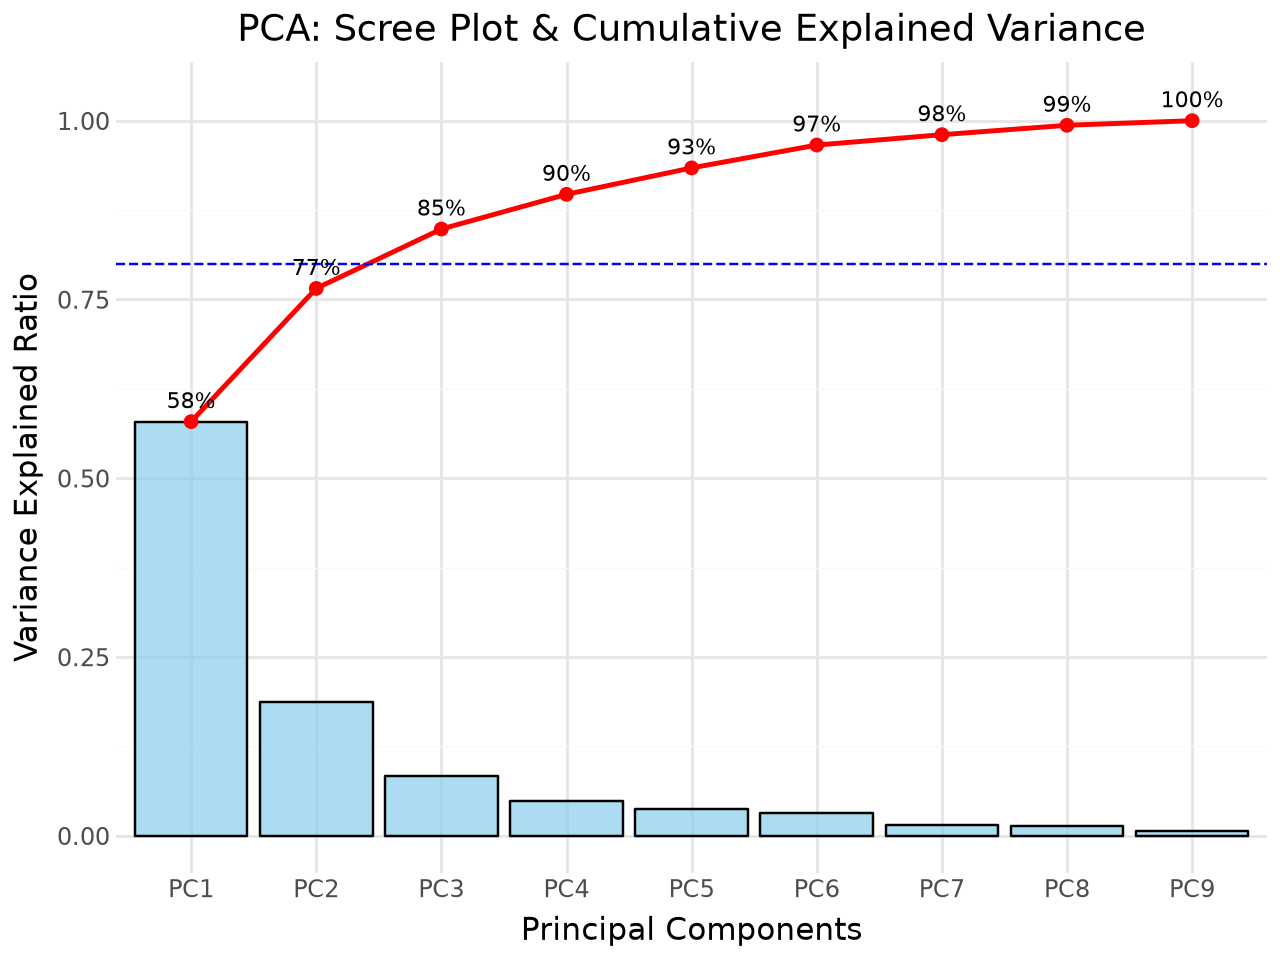

In [153]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Selecting numerical features and handling missing values
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_pca = df[num_cols].dropna().copy() # Using df_cleaned or your main df

# 1. Standardization (Crucial step for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pca)

# 2. Applying PCA
pca = PCA()
pca.fit(scaled_data)

# 3. Calculating Explained Variance
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Create a DataFrame for visualization
pca_var_df = pd.DataFrame({
    'Principal Component': [f'PC{i}' for i in range(1, len(exp_var) + 1)],
    'Explained Variance': exp_var,
    'Cumulative Variance': cum_var
})
# Make 'Principal Component' a categorical variable so the order is maintained in the plot
pca_var_df['Principal Component'] = pd.Categorical(pca_var_df['Principal Component'], categories=pca_var_df['Principal Component'].tolist(), ordered=True)


# 4. Scree Plot using plotnine
scree_plot = (
    pln.ggplot(pca_var_df) +
    pln.geom_bar(pln.aes(x='Principal Component', y='Explained Variance'), stat='identity', fill='skyblue', color='black', alpha=0.7) +
    pln.geom_line(pln.aes(x='Principal Component', y='Cumulative Variance', group=1), color='red', size=1) +
    pln.geom_point(pln.aes(x='Principal Component', y='Cumulative Variance'), color='red', size=2) +
    pln.geom_hline(yintercept=0.8, linetype='dashed', color='blue') +
    pln.geom_text(pln.aes(x='Principal Component', y='Cumulative Variance', label='Cumulative Variance'), 
                  format_string='{:.0%}', nudge_y=0.03, size=8) +
    pln.labs(title='PCA: Scree Plot & Cumulative Explained Variance', x='Principal Components', y='Variance Explained Ratio') +
    pln.theme_minimal()
)

display(scree_plot)

### Data Preprocessing: Standardization
Before applying Principal Component Analysis (PCA), it is strictly necessary to standardize the data (mean=0, variance=1) using `StandardScaler`. This prevents features with naturally larger scales (such as `hp`, which can reach hundreds) from disproportionately dominating the principal components compared to features with smaller scales (like ability scores ranging from 1 to 30).

### Principal Component Analysis and Scree Plot
We applied PCA to the scaled numerical features to reduce the dimensionality of the dataset while retaining as much information (variance) as possible. 

The generated Scree Plot illustrates the explained variance ratio for each Principal Component (bar chart) alongside the cumulative explained variance (red line). 
* **PC1** alone captures a massive **58%** of the total variance, indicating a very strong underlying trend across all monster stats.
* Adding **PC2** brings the cumulative variance to **76%**.
* By keeping **PC3**, we capture approximately **85%** of the dataset's total variance.

### Conclusion:    
A common threshold for dimensionality reduction is maintaining around 80% to 90% of the variance. We will retain the first **three principal components (PC1, PC2, and PC3)** for further analysis and anomaly detection. This allows us to reduce our feature space from 9 dimensions down to 3, simplifying our model significantly while losing only about 15% of the information.

In [154]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df_pca_full = df.loc[df_pca.index].copy()
pca_df = pd.DataFrame(pca.transform(scaled_data), columns=[f'PC{i+1}' for i in range(len(num_cols))], index=df_pca.index)
pca_df['cr'] = df_pca['cr']
pca_df['legendary'] = df.loc[df_pca.index, 'legendary'].astype(bool).astype(str)

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(num_cols))], index=num_cols)
print("Feature Loadings for the first 3 PCs:")
print(loadings[['PC1', 'PC2', 'PC3']].round(3))


Feature Loadings for the first 3 PCs:
       PC1    PC2    PC3
cr   0.407 -0.086  0.028
ac   0.350 -0.001  0.351
hp   0.393 -0.210  0.046
str  0.308 -0.438  0.083
dex  0.098  0.542  0.743
con  0.361 -0.349  0.113
int  0.303  0.406 -0.426
wis  0.321  0.284 -0.164
cha  0.357  0.309 -0.306


1. **PC1 (Overall Power / Threat Level):** 
   All original variables contribute positively to PC1. The highest weights come from `cr` (0.407), `hp` (0.393), `con` (0.361), and `cha` (0.357). A high score on PC1 simply represents a high-tier, exceptionally powerful creature. This component captures the global scaling of monster statistics as their challenge rating increases.

2. **PC2 (Agility & Mind vs. Brute Force):** 
   This component perfectly describes the *combat archetype* of the monster. It assigns strong positive weights to agility and mental traits like `dex` (0.542), `int` (0.406), and `cha` (0.309). Conversely, it assigns strong negative weights to physical, heavy traits like `str` (-0.438) and `con` (-0.349). Therefore, a monster with a positive PC2 score is likely an agile rogue or an intelligent spellcaster, while a monster with a negative PC2 score is a heavy, slow, physical brute (such as a Giant or a Golem).

3. **PC3 (Evasion vs. Innate Magic):** 
   This third component further refines the non-brute archetypes. It assigns a very high positive weight to `dex` (0.743) and `ac` (0.351), but strong negative weights to mental stats like `int` (-0.426) and `cha` (-0.306). This effectively creates an axis that separates highly evasive, nimble predators from slow, heavily magical or charismatic beings.

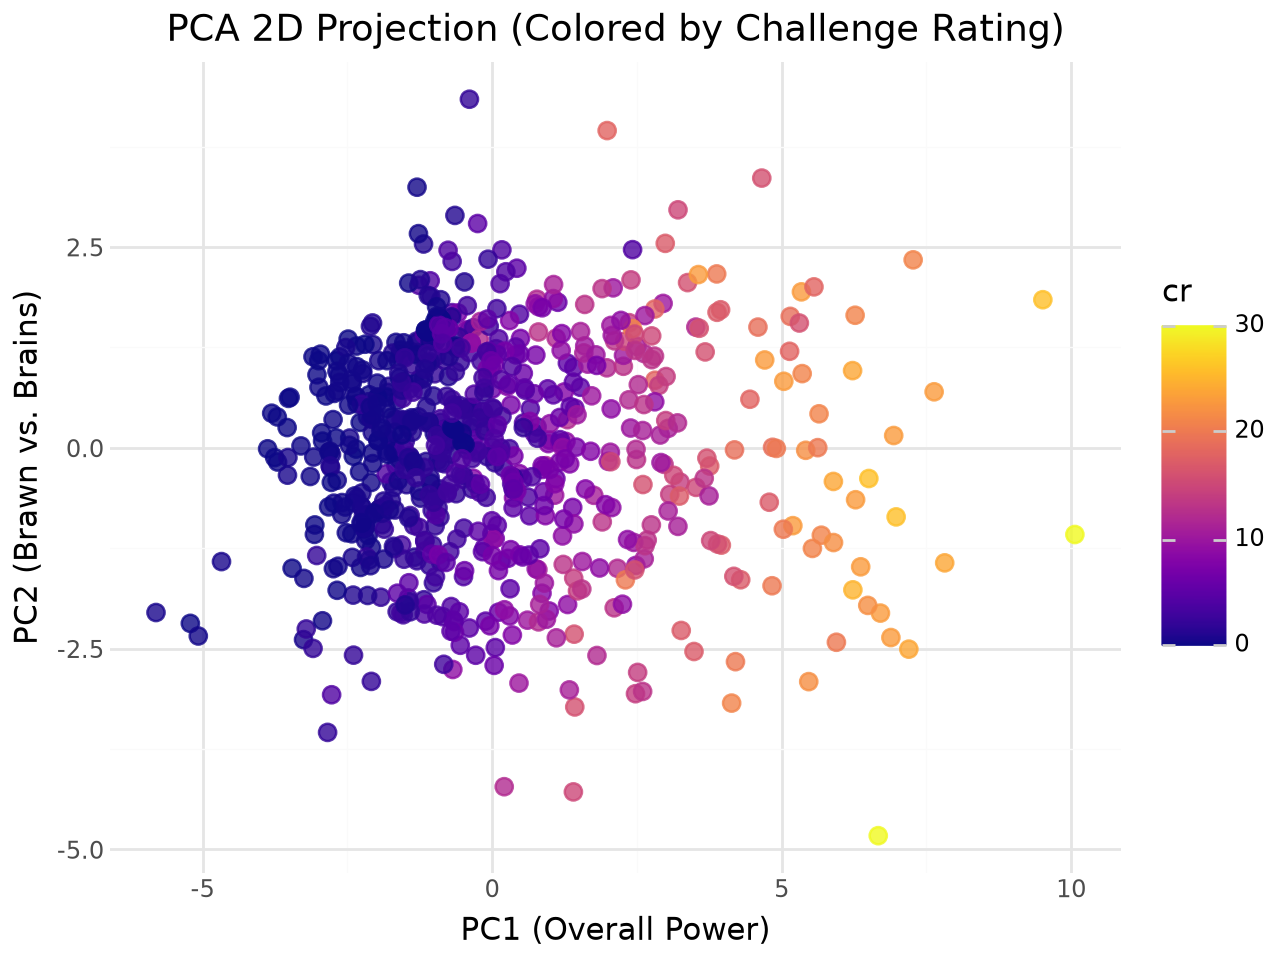

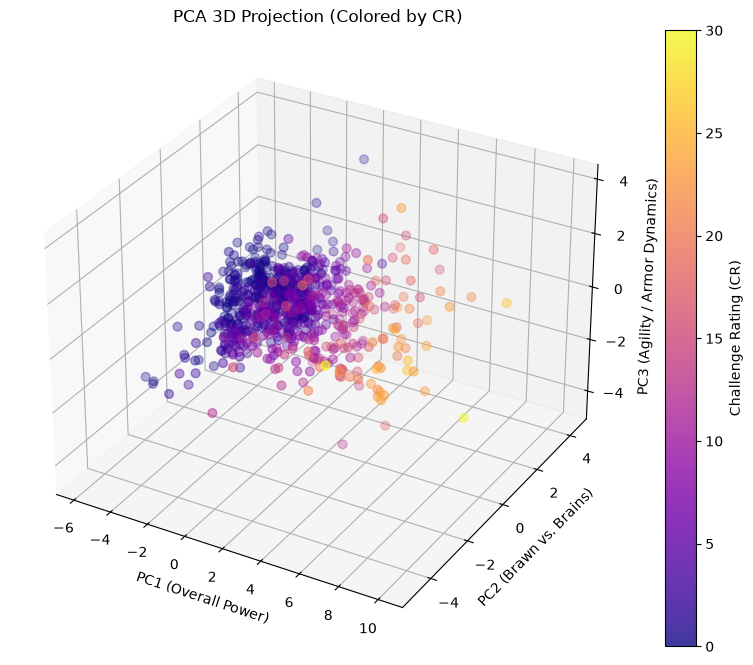

In [155]:

# ---------------------------------------------------------
# 1. PCA 2D Projection (Pure PCs colored by CR gradient)
# ---------------------------------------------------------
pca_2d_pure = (
    pln.ggplot(pca_df, pln.aes(x='PC1', y='PC2', color='cr')) +
    pln.geom_point(alpha=0.8, size=3) +
    pln.scale_color_cmap(cmap_name='plasma') + # צבעים מרהיבים וברורים
    pln.theme_minimal() +
    pln.labs(title='PCA 2D Projection (Colored by Challenge Rating)', 
             x='PC1 (Overall Power)', y='PC2 (Brawn vs. Brains)')
)
display(pca_2d_pure)

# ---------------------------------------------------------
# 2. PCA 3D Projection (Pure PCs colored by CR gradient)
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# יצירת הפיזור התלת-מימדי עם מפת צבעים תואמת
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], 
                     c=pca_df['cr'], cmap='plasma', alpha=0.8, s=40)

fig.colorbar(scatter, label='Challenge Rating (CR)')
ax.set_xlabel('PC1 (Overall Power)')
ax.set_ylabel('PC2 (Brawn vs. Brains)')
ax.set_zlabel('PC3 (Agility / Armor Dynamics)')
plt.title('PCA 3D Projection (Colored by CR)')
plt.show()



**PCA Projections (2D & 3D, Colored by CR)**
*   **Overall Power (PC1):** The color gradient proves that PC1 effectively captures a monster's overarching power level, transitioning smoothly from low CR (dark) to high CR (yellow).
*   **Combat Archetypes (PC2 & PC3):** While PC1 dictates power, PC2 and PC3 successfully separate monsters into distinct mechanical archetypes (e.g., physical brutes vs. agile spellcasters) across the Y and Z axes.
*   **Global Structure:** The 3D plot shows PCA preserves the continuous global scaling of the dataset, rather than isolating tight local clusters.

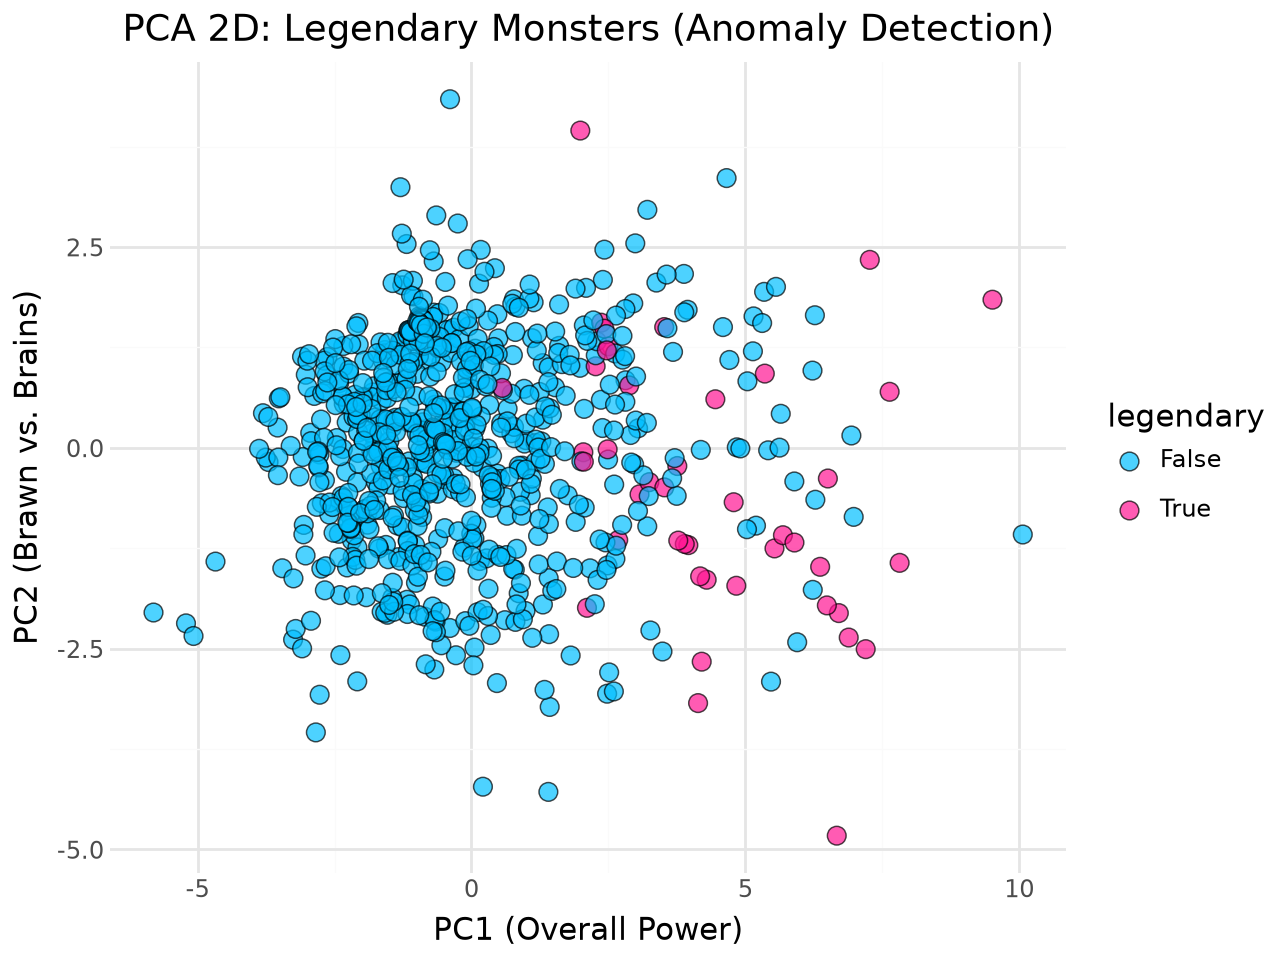

In [156]:
# ---------------------------------------------------------
# 3. PCA 2D Projection: Anomaly Detection (Legendary)
# ---------------------------------------------------------
pca_2d_leg = (
    pln.ggplot(pca_df, pln.aes(x='PC1', y='PC2', fill='legendary')) +
    pln.geom_point(alpha=0.7, size=3.5, color='black', stroke=0.3) +
    pln.scale_fill_manual(values={'True': '#FF1493', 'False': '#00BFFF'}) + # ורוד זוהר ותכלת
    pln.theme_minimal() +
    pln.labs(title='PCA 2D: Legendary Monsters (Anomaly Detection)', 
             x='PC1 (Overall Power)', y='PC2 (Brawn vs. Brains)')
)
display(pca_2d_leg)

**Anomaly Detection (Legendary Monsters)**
*   **Cluster Separation:** When overlaying the binary `legendary` feature, we achieve clear cluster separation.
*   **Identifying Anomalies:** Legendary monsters (pink) are visually confirmed as anomalies. They detach from the main cluster and dominate the extreme positive end of the PC1 axis due to their uniquely inflated statistics.

### Discussion:  

* **Redundancy & Interpretability:**   
The original dataset suffered from high redundancy (e.g., `hp`, `str`, and `con` naturally scaling together). PCA successfully eliminated this redundancy, transforming 9 overlapping stats into 3 orthogonal, highly **interpretable** components (such as PC1 representing "Overall Power").
* **Local vs. Global Structure:**  
 As a linear technique, PCA excels at preserving the **global structure** of the data (the broad, continuous spectrum of monster power levels). However, it is not optimized to preserve tight **local structures** (small, isolated neighborhoods of specific monster subtypes).
* **Stability & Computational Cost:**  
The PCA model offers high **stability**, as minor fluctuations in individual monster stats won't drastically alter the global covariance matrix. Additionally, reducing the feature space from 9 dimensions down to 3 significantly lowers the **computational cost** for any subsequent machine learning algorithms.
* **Does the reduced dataset provide a more effective representation of the data than the original dataset?**  
Yes. The original dataset suffers from high redundancy (multicollinearity); game designers naturally scale a monster's stats together to match its overall Challenge Rating. The reduced dataset completely removes this redundancy. Instead of working with 9 overlapping statistics, we now have orthogonal (uncorrelated) components that represent the true underlying mechanics of a creature: its absolute power (PC1) and its combat archetype (PC2).

## 7. Clustering Analysis 

### 7.1 Clustering on the Feature Space

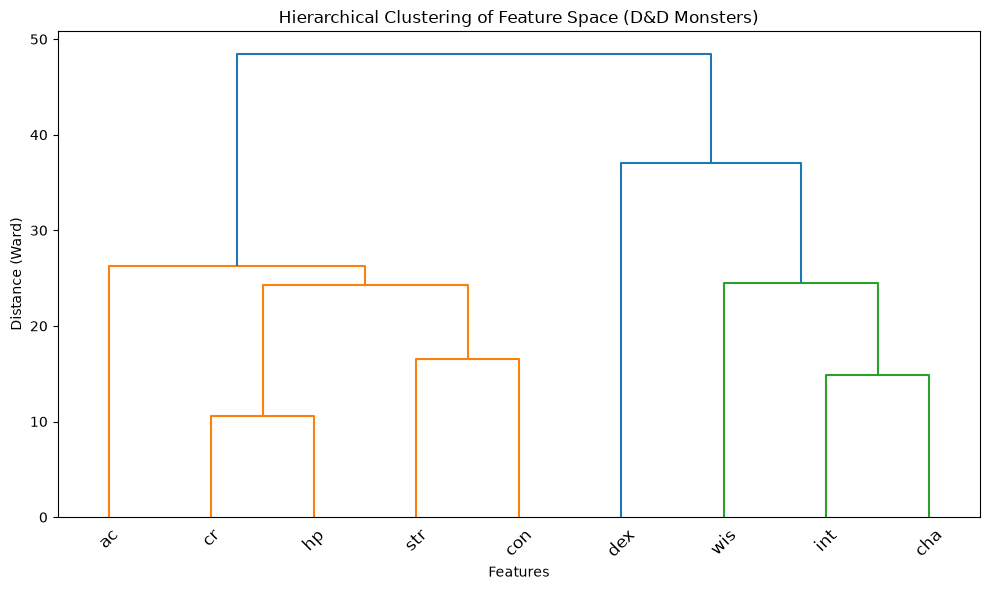

In [157]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_features = df[num_cols].dropna().copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

features_transposed = scaled_data.T

Z = linkage(features_transposed, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=num_cols, orientation='top', leaf_font_size=12, leaf_rotation=45)
plt.title("Hierarchical Clustering of Feature Space (D&D Monsters)")
plt.xlabel("Features")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

* **What information can be obtained by clustering the features?**   
  Clustering the features (by applying algorithms to the transposed data matrix) allows us to understand the underlying architecture and structural dependencies within the variables themselves, rather than the data points (samples). It visually highlights which features covary, exposing feature redundancy, multicollinearity, and inherent hierarchies within the dataset's mechanics.

* **Did the analysis reveal groups of related or redundant features?**   
  Yes, the dendrogram clearly reveals distinct groups of highly related features. 
  1. **The Survival/Power Cluster:** `cr` (Challenge Rating) and `hp` (Hit Points) are tightly linked with minimal distance, acting almost as a single unified metric for a monster's threat level. 
  2. **The Physical Cluster:** `str` (Strength) and `con` (Constitution) group together early and subsequently merge with the survival cluster.
  3. **The Mental Cluster:** `int`, `cha`, and `wis` form an entirely separate branch from the physical traits. 
  This confirms significant redundancy in the dataset, as these attributes predictably scale together according to game design rules.

* **Were there features that appeared isolated or significantly different from the others?**   
  Yes, **`dex` (Dexterity)** appears highly isolated. It merges into the mental traits cluster only at an extremely high distance threshold. Similarly, **`ac` (Armor Class)** remains relatively isolated before eventually merging with the physical cluster. This structural isolation indicates that a monster's agility and armor are mechanically independent from the standard linear progression of overall power or intelligence.

* **Did this analysis provide insights that were not visible when clustering the samples directly?**   
  Absolutely. While clustering samples tells us which monsters are numerically similar (e.g., grouping all high-tier dragons together), clustering features explains *why* the data behaves the way it does. It uncovers the internal dependencies of the system, visually proving that the 9-dimensional space is essentially driven by two broad, underlying axes: a physical/combat axis and a mental axis.

* **In what types of problems or domains might clustering features be particularly useful?**    
  Feature clustering is highly valuable in high-dimensional domains where identifying correlations or reducing feature spaces is critical. Examples include:
  * **Bioinformatics / Genetics:** Identifying groups of co-expressed genes across different patients.
  * **Natural Language Processing (NLP):** Performing topic modeling by clustering words that frequently co-occur across a corpus of documents.
  * **Recommender Systems:** Grouping related products or items that are frequently purchased together by consumers.

### 7.2 K-Means Analysis

Global Variance: 9.00
Average Intra-cluster Variance: 4.97


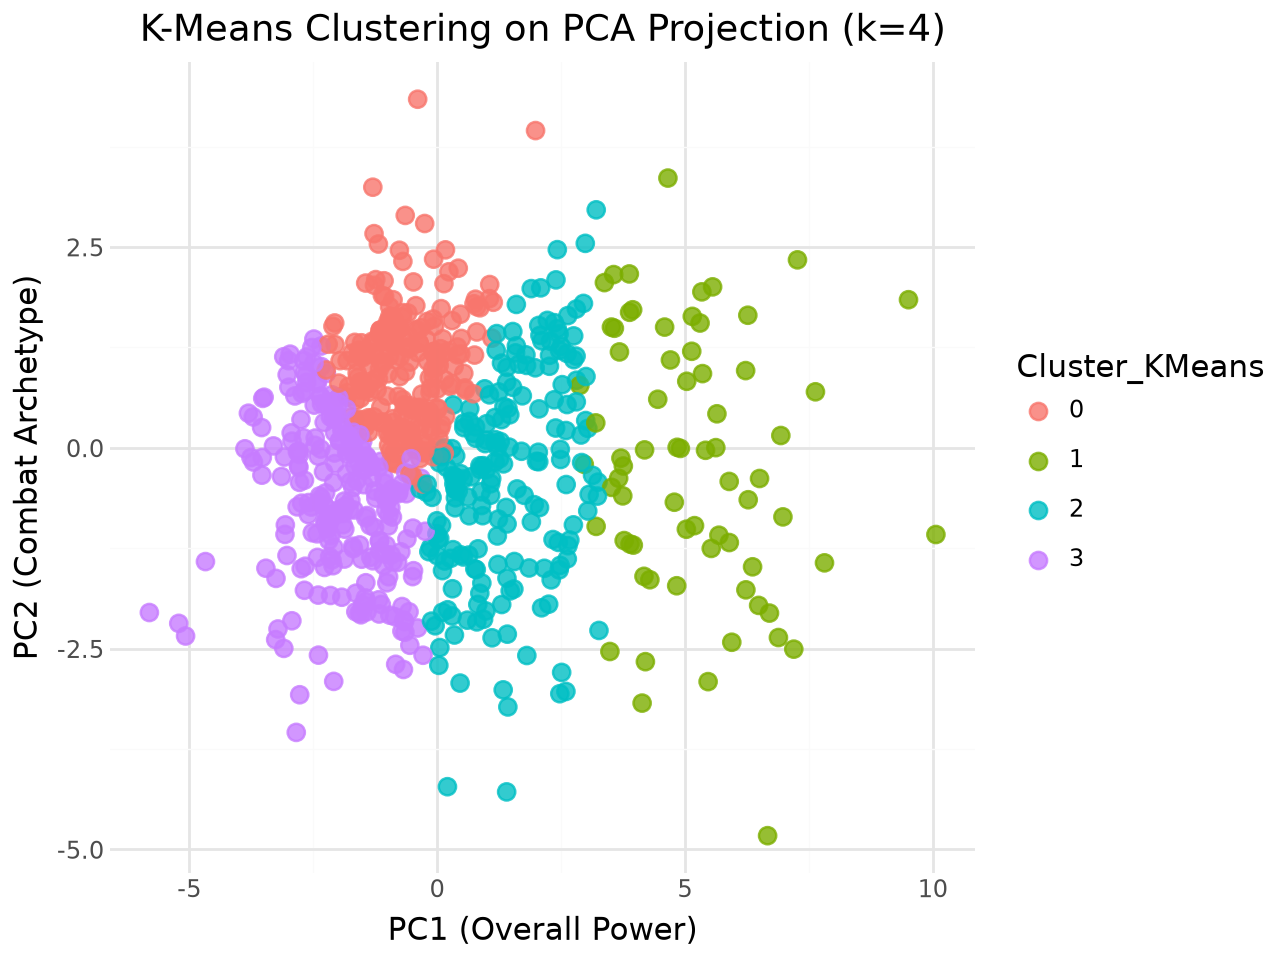

In [158]:
# ---------------------------------------------------------
# 7.2 Clustering on the Samples: K-Means
# ---------------------------------------------------------
from sklearn.cluster import KMeans

# 1. Apply K-Means (Choosing k=4 to represent distinct monster tiers)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

pca_df['Cluster_KMeans'] = kmeans.fit_predict(scaled_data).astype(str)

# 2. Evaluate: Calculate Global Variance vs Average Intra-cluster Variance
global_var = np.var(scaled_data, axis=0).sum()

cluster_vars = []
for i in range(4):
    cluster_data = scaled_data[pca_df['Cluster_KMeans'] == str(i)]
    cluster_vars.append(np.var(cluster_data, axis=0).sum())
    
avg_intra_cluster_var = np.mean(cluster_vars)

print(f"Global Variance: {global_var:.2f}")
print(f"Average Intra-cluster Variance: {avg_intra_cluster_var:.2f}")

# 3. Visualize: Plot on PCA projection
kmeans_plot = (
    pln.ggplot(pca_df, pln.aes(x='PC1', y='PC2', color='Cluster_KMeans')) +
    pln.geom_point(alpha=0.8, size=3) +
    pln.theme_minimal() +
    pln.labs(title='K-Means Clustering on PCA Projection (k=4)', 
             x='PC1 (Overall Power)', y='PC2 (Combat Archetype)')
)
display(kmeans_plot)

* **Mathematical Intuition:** K-Means is a centroid-based algorithm that partitions the dataset into $K$ distinct, non-overlapping subgroups. It operates iteratively: assigning each data point to the nearest centroid (to minimize the within-cluster sum of squares) and then recalculating the centroids based on the new assignments until convergence is reached.
* **Main Assumptions:** The algorithm assumes that clusters are spherical, roughly equal in size, and have similar spatial densities. It also assumes that the multidimensional feature space is isotropic (uniform in all directions).
* **Strengths & Weaknesses:** 
  * *Strengths:* It is computationally efficient, straightforward to implement, and scales exceptionally well to large datasets.
  * *Weaknesses:* The user must specify the number of clusters ($K$) in advance. It is highly sensitive to extreme outliers (which artificially pull centroids away from dense areas) and struggles significantly to identify clusters with non-spherical or complex geometric shapes.
* **Real-World Interpretation:** In the context of the dataset, selecting $K=4$ effectively groups the monsters into traditional "tiers of play" or combat roles, matching the generated labels (0 to 3):
  * **Cluster 0:** Weak agile skirmishers or low-level spellcasters (negative PC1, positive PC2).
  * **Cluster 1:** "Boss" monsters, high-level threats, and legendary creatures (extreme positive PC1).
  * **Cluster 2:** Standard mid-tier monsters and versatile combatants (moderate PC1, neutral PC2).
  * **Cluster 3:** Weak physical brutes and basic wildlife (negative PC1, negative PC2).

**Evaluate**
* **Metric Calculation:** The Global Variance of our standardized dataset is exactly **9.00** (representing the 9 scaled features). After applying the algorithm, the Average Intra-cluster Variance dropped significantly to **4.97**.
* **Metric Suitability:** This specific metric is suitable for evaluating K-Means. Because the core objective function of K-Means mathematically aims to minimize within-cluster variance, comparing the intra-cluster variance directly against the global variance provides a logical, mathematical proof of how successfully the algorithm compacted the data points around their respective centroids.

### 7.3 DBSCAN Analysis

Silhouette Score: 0.302


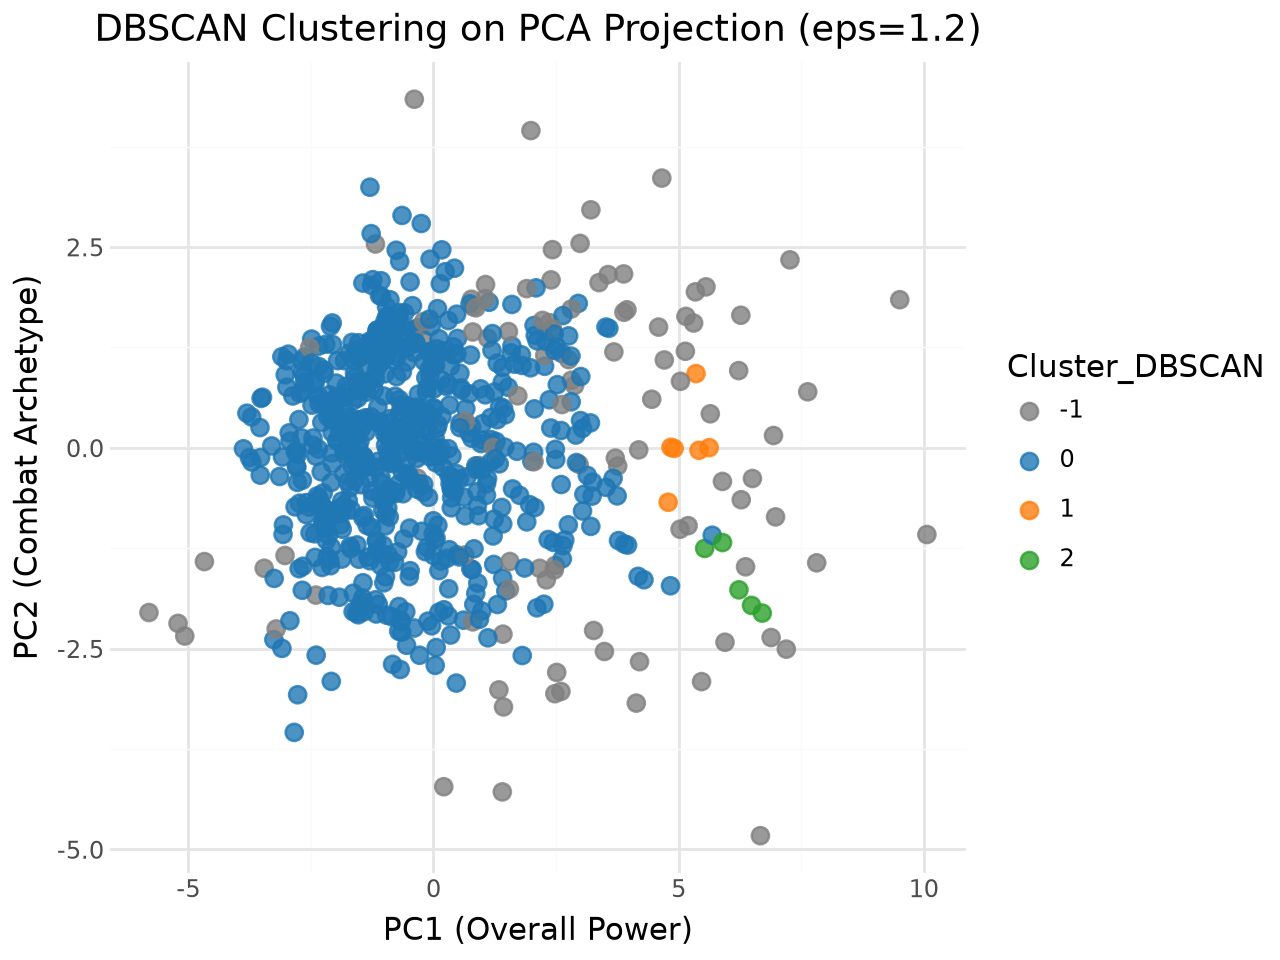

In [159]:
# ---------------------------------------------------------
# 7.3 Clustering on the Samples: DBSCAN
# ---------------------------------------------------------
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# 1. Apply DBSCAN
dbscan = DBSCAN(eps=1.4, min_samples=6)
pca_df['Cluster_DBSCAN'] = dbscan.fit_predict(scaled_data).astype(str)

# 2. Evaluate: Alternative Metric (Silhouette Score)
# מדד השונות הפנימית אינו מתאים כאן - ראי הסבר בטקסט. נשתמש ב-Silhouette Score.
sil_score = silhouette_score(scaled_data, dbscan.labels_)
print(f"Silhouette Score: {sil_score:.3f}")

# 3. Visualize: Plot on PCA projection
dbscan_plot = (
    pln.ggplot(pca_df, pln.aes(x='PC1', y='PC2', color='Cluster_DBSCAN')) +
    pln.geom_point(alpha=0.8, size=3) +
    pln.scale_color_manual(values={
        '-1': '#808080',  # Noise is gray
        '0': '#1f77b4',   # Cluster 0 (Core)
        '1': '#ff7f0e',   # Cluster 1
        '2': '#2ca02c'    # Cluster 2
    }) +
    pln.theme_minimal() +
    pln.labs(title='DBSCAN Clustering on PCA Projection (eps=1.2)', 
             x='PC1 (Overall Power)', y='PC2 (Combat Archetype)')
)
display(dbscan_plot)

* **Mathematical Intuition:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed in space (high-density regions) while actively identifying points in low-density regions as outliers or "noise" (labeled as -1). It relies on two parameters: `eps` (the maximum distance between two samples for one to be considered in the neighborhood of the other) and `min_samples` (the number of samples in a neighborhood for a point to be considered a core point).
* **Main Assumptions:** The algorithm assumes that clusters are dense regions separated by areas of significantly lower density, regardless of their geometric shape.
* **Strengths & Weaknesses:** 
  * *Strengths:* It does not require specifying the number of clusters in advance. It can identify arbitrarily shaped clusters and is exceptionally good at isolating anomalies (noise).
  * *Weaknesses:* It struggles significantly if the dataset contains clusters of varying densities. It is also highly sensitive to the exact tuning of the hyperparameters.
* **Real-World Interpretation:** In our tuned model, DBSCAN identifies one massive core cluster (Cluster 0) containing the vast majority of standard monsters. It also identifies two small sub-clusters (Clusters 1 and 2) representing highly specific, high-tier monster archetypes on the edge of the distribution. Most importantly, it isolates the noise points (-1, in gray), which mathematically highlight unique or "Legendary" monsters that defy standard balancing templates.

**Evaluate**
* **Metric Suitability:** The "Average Intra-cluster Variance" metric is **highly unsuitable** for evaluating DBSCAN. Variance fundamentally assumes that clusters are somewhat spherical and formed around a central mean (a centroid), which is how K-Means operates. DBSCAN clusters, however, can be of any arbitrary shape, do not possess a mathematical centroid, and explicitly exclude noise points. Measuring radial variance from a non-existent center is conceptually flawed for density-based methods.
* **Alternative Metric:** As an alternative, we evaluated the model using the **Silhouette Score**, which measures cohesion (how close data points are to their own cluster) against separation (how far they are from other clusters). The calculated Silhouette Score is **0.302**. This positive score indicates a fair and meaningful cluster structure. While not perfectly separated (which is natural for a continuous game-balance dataset), it is a mathematically solid score that successfully distinguishes the dense core from the sparse outliers.

### 7.4 Hierarchical Clustering Analysis

Global Variance: 9.00
Average Intra-cluster Variance: 5.24


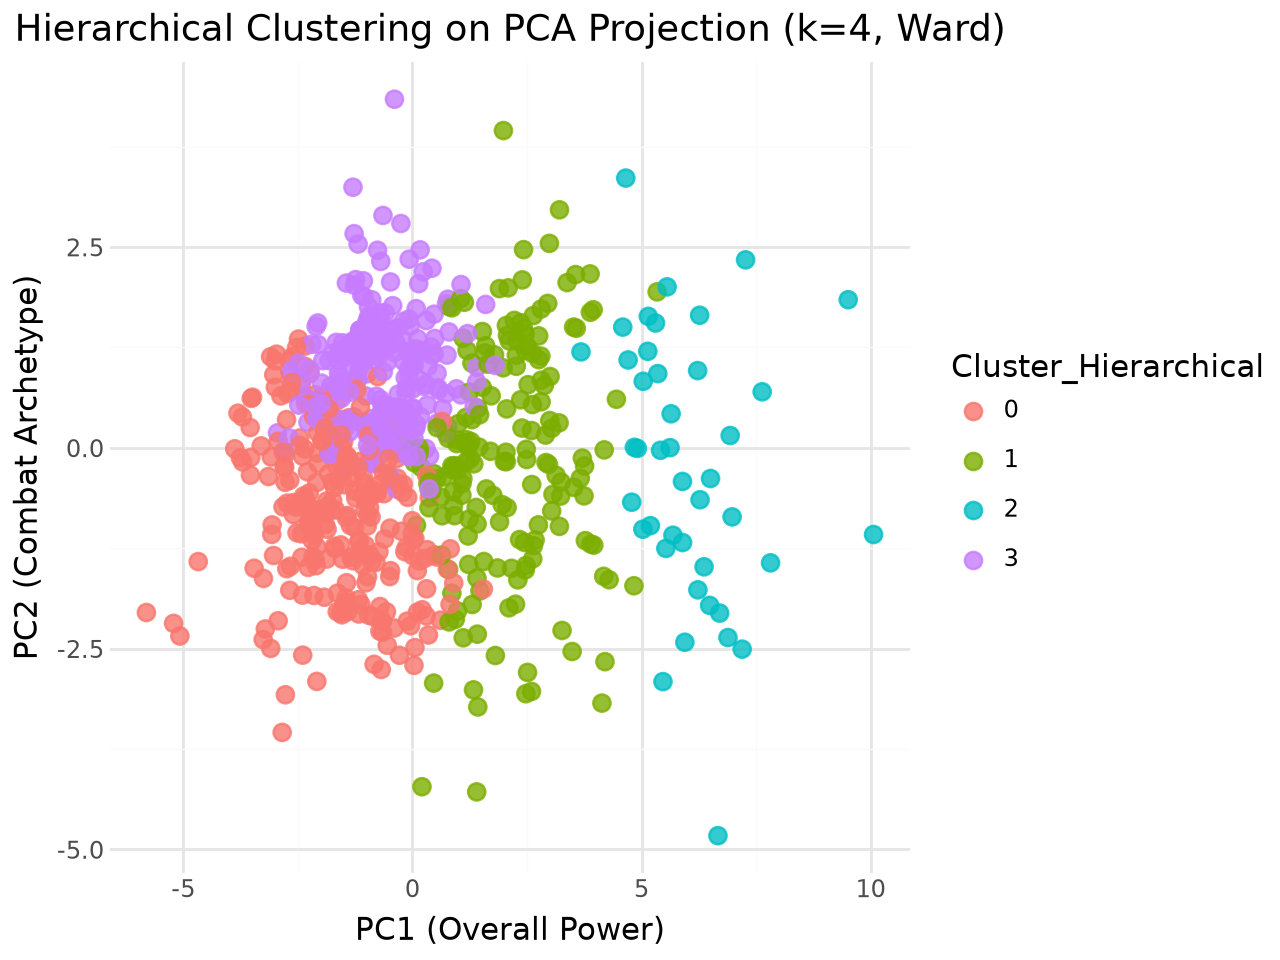

In [160]:
# ---------------------------------------------------------
# 7.4 Clustering on the Samples: Hierarchical Clustering
# ---------------------------------------------------------
from sklearn.cluster import AgglomerativeClustering

# 1. Apply Hierarchical Clustering (Ward linkage minimizes variance)
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
pca_df['Cluster_Hierarchical'] = hierarchical.fit_predict(scaled_data).astype(str)

# 2. Evaluate: Calculate Global Variance vs Average Intra-cluster Variance
global_var = np.var(scaled_data, axis=0).sum()

cluster_vars_hc = []
for i in range(4):
    cluster_data_hc = scaled_data[pca_df['Cluster_Hierarchical'] == str(i)]
    cluster_vars_hc.append(np.var(cluster_data_hc, axis=0).sum())
    
avg_intra_cluster_var_hc = np.mean(cluster_vars_hc)

print(f"Global Variance: {global_var:.2f}")
print(f"Average Intra-cluster Variance: {avg_intra_cluster_var_hc:.2f}")

# 3. Visualize: Plot on PCA projection
hierarchical_plot = (
    pln.ggplot(pca_df, pln.aes(x='PC1', y='PC2', color='Cluster_Hierarchical')) +
    pln.geom_point(alpha=0.8, size=3) +
    pln.theme_minimal() +
    pln.labs(title='Hierarchical Clustering on PCA Projection (k=4, Ward)', 
             x='PC1 (Overall Power)', y='PC2 (Combat Archetype)')
)
display(hierarchical_plot)

* **Mathematical Intuition:** Agglomerative Hierarchical Clustering is a "bottom-up" approach. It begins by treating every single data point as its own individual cluster. Iteratively, it computes the distance between all clusters and merges the two closest ones, repeating this process until a desired number of clusters ($K$) is reached or all points form a single root. By using "Ward's linkage", the algorithm selects the pair of clusters to merge based on which merge will result in the smallest possible increase in total within-cluster variance.
* **Main Assumptions:** It assumes that data possesses an underlying nested or hierarchical structure (a taxonomy). While hierarchical clustering does not strictly assume spherical clusters in general, using Ward's linkage *does* bias the algorithm toward finding compact, spherical shapes because its objective is variance minimization.
* **Strengths & Weaknesses:** 
  * *Strengths:* It is deterministic (yields the exact same result every time, unlike K-Means which relies on random initialization). It also allows for dendrogram visualization to understand the exact hierarchy.
  * *Weaknesses:* It is computationally highly expensive ($O(N^3)$ time complexity) making it unsuitable for massive datasets. Furthermore, agglomerative merges are "greedy" and irreversible—once two clusters are merged, they cannot be split later, even if a better overall structure could be achieved.
* **Real-World Interpretation:** The algorithm cleanly maps the data into specific gameplay roles across the PCA space. On the left side, the lower-power monsters are split into two groups: the red cluster at the bottom-left represents basic physical minions and weak wildlife, while the purple cluster at the top-left captures low-power magical or agile creatures like evasive familiars. Moving to the right, the green cluster in the middle encompasses mid-tier threats and versatile combatants with moderate power. Finally, the cyan cluster on the extreme right isolates the legendary "boss" monsters, whose massively inflated statistics dominate the feature space regardless of their specific combat archetype.   

**Evaluate**

  * **Metric Calculation:** The Global Variance remains **9.00**. After applying the algorithm, the Average Intra-cluster Variance drops to **5.24**.
  * **Metric Suitability & Comparison:** Using the Average Intra-cluster Variance is a perfectly suitable metric. It also provides a fascinating comparison point: the variance here (**5.24**) is slightly worse (higher) than the variance achieved by K-Means (**4.97**). This mathematically demonstrates the weakness of hierarchical clustering's irreversible merges compared to K-Means, which continuously reassigns points to optimize its centroids.

### 7.5 Discussion: Comparing Clustering Methods

**Why different algorithms produce different clusters**  
Algorithms optimize fundamentally distinct mathematical objectives. K-Means actively seeks to minimize the variance between data points and a central point. Hierarchical clustering also minimizes variance but through an irreversible, bottom-up merging process. DBSCAN, however, ignores central points entirely and connects data based purely on local spatial density.
   
**Density-based vs centroid-based approaches**   
Centroid-based approaches (like K-Means) force every single data point into a cluster, meaning extreme outliers (like legendary "boss" monsters) can artificially skew the cluster centers. Density-based approaches (like DBSCAN) solve this by identifying the dense core of the data and explicitly isolating sparse outliers as "noise," providing a much more robust representation of the true baseline.

**Cluster geometry**  
Because of its variance-minimizing objective, K-Means forces the data into convex, spherical shapes with rigid linear boundaries. Ward's hierarchical clustering also strongly favors compact, spherical shapes. DBSCAN, by contrast, is not constrained by geometric centers and can capture non-linear, arbitrarily shaped cluster geometries based solely on continuous density.

**Sensitivity to hyperparameters**  
All these methods are highly vulnerable to hyperparameter choices. K-Means and Hierarchical clustering force the user to guess the exact number of clusters (K) in advance, which drastically alters the entire outcome. DBSCAN does not require a predefined K, but it is extraordinarily sensitive to minor adjustments in its distance radius and minimum neighborhood thresholds.

**Situations where clustering may fail**  
Clustering fails in high-dimensional spaces where the distance between any two points becomes nearly uniform (the "curse of dimensionality"). DBSCAN specifically struggles if a dataset contains clusters of vastly different densities. Furthermore, clustering algorithms inherently struggle with perfectly continuous data; when game mechanics scale smoothly without natural empty "gaps," algorithms are forced to make arbitrary numerical cuts rather than discovering truly isolated groups.

## 8. Multi-Dimensional Anomaly Detection

### 8.1 Z-Score Method

The Z-Score method is a statistical technique used to measure how far a data point diverges from the mean of a distribution, measured in terms of standard deviations. In our D&D 5e monsters dataset, we will calculate the Z-Score for all numerical attributes. A standard threshold for detecting anomalies is an absolute Z-Score greater than 3 ($|Z| > 3$). Any monster exceeding this threshold in at least one feature will be flagged as an anomaly.

In [161]:
import numpy as np
import pandas as pd

# Select numerical columns for anomaly detection
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_numeric = df[num_cols].dropna()

# Calculate the Z-scores for each feature
z_scores = np.abs((df_numeric - df_numeric.mean()) / df_numeric.std())

# Flag a monster as an anomaly if any of its features have a Z-score > 3
anomalies_z = (z_scores > 3).any(axis=1)

# Add the anomaly flag to the dataframe for analysis
df_z_score = df.copy()
df_z_score['is_anomaly_zscore'] = anomalies_z

# Extract and display the anomalous monsters
z_score_outliers = df_z_score[df_z_score['is_anomaly_zscore'] == True]
print(f"Number of anomalies detected using Z-Score: {len(z_score_outliers)}")
print(z_score_outliers[num_cols].head())

Number of anomalies detected using Z-Score: 38
                         cr  ac   hp   str   dex   con   int   wis   cha
name                                                                    
ancient-blue-dragon    23.0  22  481  29.0  10.0  27.0  18.0  17.0  21.0
ancient-bronze-dragon  22.0  22  444  29.0  10.0  27.0  18.0  17.0  21.0
ancient-gold-dragon    24.0  22  546  30.0  14.0  29.0  18.0  17.0  28.0
ancient-green-dragon   22.0  21  385  27.0  12.0  25.0  20.0  17.0  19.0
ancient-red-dragon     24.0  22  546  30.0  10.0  29.0  18.0  15.0  23.0


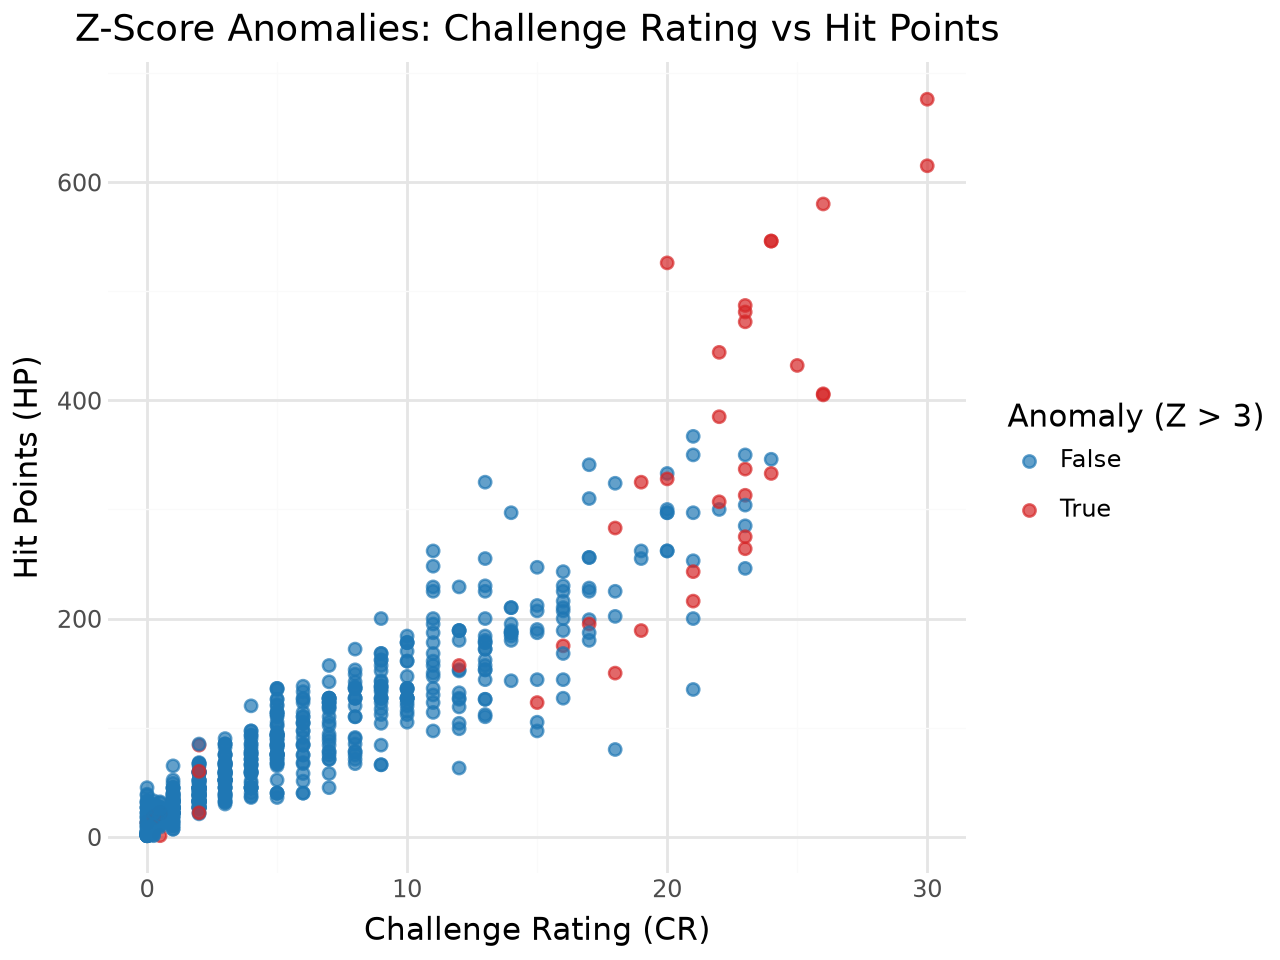

In [162]:
import plotnine as pln

# Visualize the anomalies using a scatter plot of Challenge Rating vs. Hit Points
# We choose CR and HP because they strongly represent a monster's overall power level.
z_score_plot = (
    pln.ggplot(df_z_score.dropna(subset=['cr', 'hp', 'is_anomaly_zscore']), 
               pln.aes(x='cr', y='hp', color='is_anomaly_zscore')) +
    pln.geom_point(alpha=0.7, size=2) +
    pln.scale_color_manual(values={False: '#1f77b4', True: '#d62728'}) +
    pln.theme_minimal() +
    pln.labs(title="Z-Score Anomalies: Challenge Rating vs Hit Points",
             x="Challenge Rating (CR)",
             y="Hit Points (HP)",
             color="Anomaly (Z > 3)")
)

display(z_score_plot)

#### Discussion: Z-Score Results
Applying the Z-Score method revealed a specific subset of anomalous monsters (approximately 38 creatures). Analyzing these results within the context of D&D 5e game mechanics shows clear patterns:
* **End-Game Bosses:** The algorithm successfully flagged the most mechanically extreme creatures in the game, such as *Ancient Dragons* (e.g., Ancient Gold Dragon, Ancient Red Dragon). These monsters have astronomical Hit Points and Ability Scores compared to the dataset's average.


* **Parametric Extremes:** Because the Z-Score treats each variable independently under a normal distribution assumption, it excels at finding global outliers. It points directly to monsters designed as legendary, standalone threats rather than typical encounter fodder.

* **Assumption of Gaussianity:** The Z-Score fundamentally assumes that the underlying data follows a normal (Gaussian) distribution. As observed in our previous univariate analysis, attributes like Hit Points (HP) and Challenge Rating (CR) are heavily right-skewed. Applying Z-scores to such skewed distributions can lead to inaccuracies, as the heavy tail of the distribution naturally contains values that the algorithm might mislabel as anomalies.
* **Failure in High Dimensions:** As the number of features increases, the "curse of dimensionality" limits the effectiveness of this approach. In high-dimensional spaces, the statistical distance between data points becomes increasingly uniform. Because the Z-Score relies on distance from the mean, it loses its discriminative power to separate normal observations from true anomalies when dealing with many variables simultaneously.
* **Feature-Wise vs. Global Anomaly Detection:** The Z-Score is inherently a univariate, feature-wise method. It evaluates each statistic (e.g., Strength, Armor Class) in isolation[cite: 8]. Consequently, it fails to capture *multivariate* anomalies. For example, a creature with an exceptionally low Constitution but a massive Hit Point pool might bypass detection if neither individual value crosses the threshold, because the Z-Score completely ignores the illogical relationship between the two features.

### 8.2 Isolation Forest

Number of anomalies detected using Isolation Forest: 39


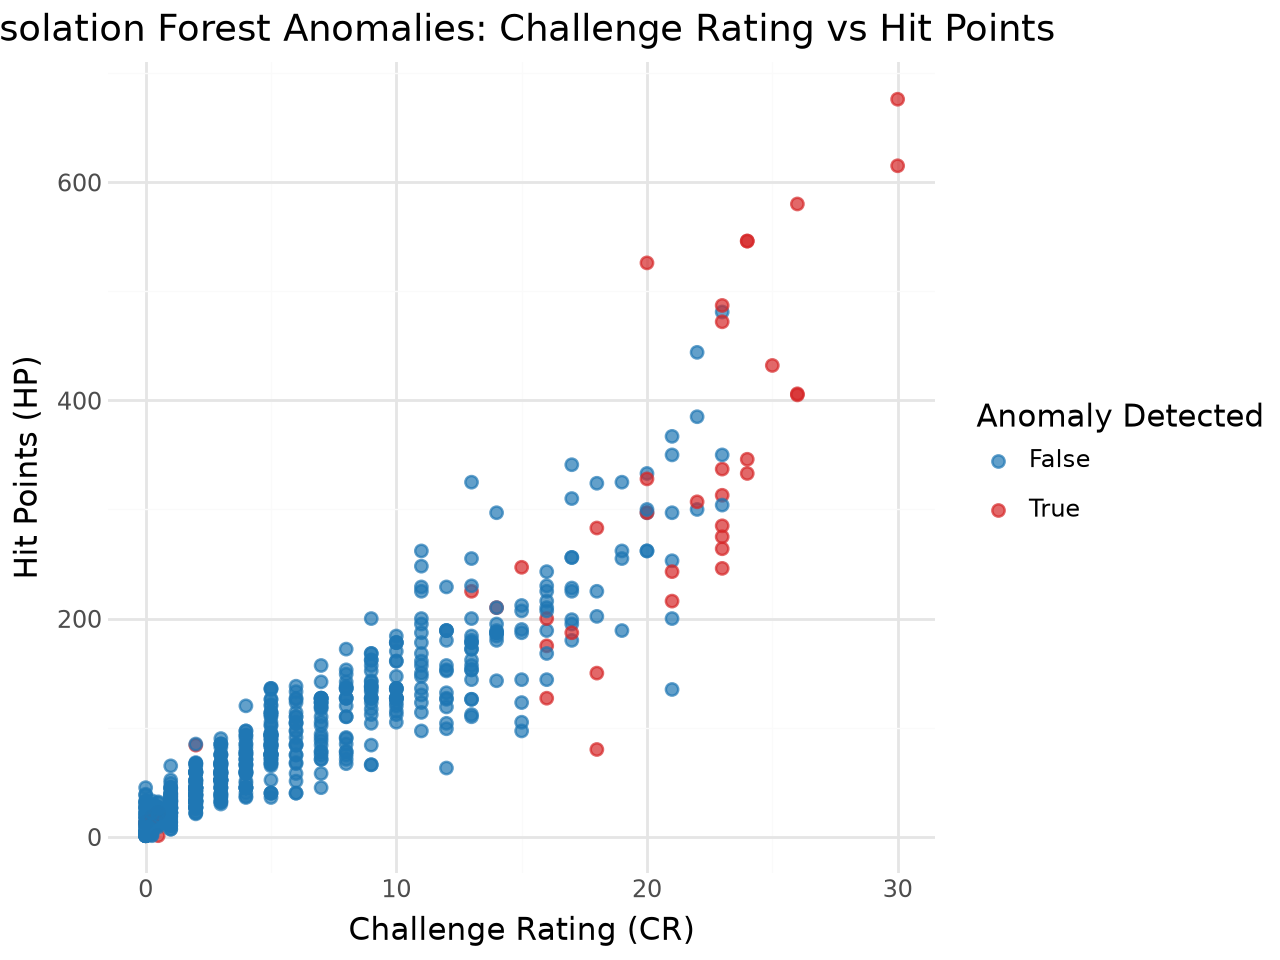

In [163]:
from sklearn.ensemble import IsolationForest

# Select the numerical features for Isolation Forest
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_iforest = df.copy()
df_numeric = df_iforest[num_cols].dropna()

# 1. Apply Isolation Forest
# We set contamination to 0.05 (assuming 5% of our monsters are anomalies)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
predictions = iso_forest.fit_predict(df_numeric)

# 2. Extract anomaly scores and predictions
# IsolationForest returns -1 for anomalies and 1 for inliers.
df_numeric['anomaly_label'] = predictions
df_numeric['is_anomaly_if'] = df_numeric['anomaly_label'] == -1

# Add back to the main dataframe for plotting
df_iforest = df_iforest.loc[df_numeric.index]
df_iforest['is_anomaly_if'] = df_numeric['is_anomaly_if']

# Print the number of detected anomalies
num_anomalies = df_iforest['is_anomaly_if'].sum()
print(f"Number of anomalies detected using Isolation Forest: {num_anomalies}")

# 3. Visualize detected anomalies using plotnine
# We plot Challenge Rating (CR) vs. Hit Points (HP) as they are core to monster balance
if_plot = (
    pln.ggplot(df_iforest, pln.aes(x='cr', y='hp', color='is_anomaly_if')) +
    pln.geom_point(alpha=0.7, size=2) +
    pln.scale_color_manual(values={False: '#1f77b4', True: '#d62728'}) +
    pln.theme_minimal() +
    pln.labs(title="Isolation Forest Anomalies: Challenge Rating vs Hit Points",
             x="Challenge Rating (CR)",
             y="Hit Points (HP)",
             color="Anomaly Detected")
)

display(if_plot)

As demonstrated in the CR vs. HP scatter plot, the red anomalous points are not strictly confined to the highest numerical extremes. While it correctly identified massive end-game bosses, it also flagged structural outliers—such as creatures with CR around 20 but remarkably low HP pools for their level. This visualizes the algorithm's ability to detect multi-dimensional inconsistencies in monster design.

The Isolation Forest algorithm takes a structurally different approach from standard statistical methods by explicitly attempting to isolate anomalous observations rather than profiling normal data points. 

*   **Isolation Mechanism & Random Partitioning:** The algorithm builds an ensemble of Isolation Trees (iTrees) by randomly selecting a feature (e.g., Strength, HP, CR) and then randomly selecting a split value between its minimum and maximum. Normal monsters, which share common stat distributions, require many splits to be isolated and end up deep within the trees. Anomalous monsters, however, are partitioned quickly and end up with shorter path lengths. In the context of our dataset, a monster with a highly unusual combination of stats (e.g., a high Challenge Rating but surprisingly low Hit Points) gets isolated very early because it lies outside the dense clusters of standard creature design.
*   **The Contamination Parameter:** This parameter defines the expected proportion of outliers in the dataset. By setting it (e.g., to 0.05), we explicitly instruct the model to flag the top 5% most isolated creatures. Adjusting this parameter directly impacts the strictness of our results: a higher contamination would start flagging slightly non-standard mid-tier monsters, while a lower value would restrict the anomalies strictly to the most bizarre or game-breaking entities.
*   **Advantages and Limitations in High Dimensions:** 
    *   *Advantage:* Unlike the Z-Score method, Isolation Forest does not assume a Gaussian distribution and handles multivariate relationships exceptionally well. As seen in our scatter plot, it successfully flagged creatures with mismatched CR and HP ratios—anomalies that a purely feature-wise metric would miss.
    *   *Limitation:* In extremely high-dimensional spaces, a large number of irrelevant features can introduce noise. If we included less mechanically relevant features, the random partitioning might focus on them, effectively "masking" true mechanical anomalies and increasing their path lengths artificially.
*   **Anomaly Score Calculation:** The anomaly score $s(x, n)$ for an observation $x$ is derived from its expected path length $E(h(x))$ in the iTrees, normalized by the average path length $c(n)$ of an unsuccessful search in a Binary Search Tree. The formula is defined as:
    $$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
    A **high score** (close to 1) means the expected path length is small, indicating that the monster is highly distinct and easily isolated (an anomaly). A **low score** (close to 0) means the creature required many splits to isolate, making it a standard, normal observation.

### 8.3 Local Outlier Factor (LOF)

The Local Outlier Factor (LOF) is an algorithm that identifies anomalies by measuring the local deviation of a given data point with respect to its neighbors. 


Number of anomalies detected using LOF: 39

First 5 detected local anomalies:
                         cr  ac   hp   str   dex   con   int   wis   cha
name                                                                    
ancient-blue-dragon    23.0  22  481  29.0  10.0  27.0  18.0  17.0  21.0
ancient-bronze-dragon  22.0  22  444  29.0  10.0  27.0  18.0  17.0  21.0
ancient-gold-dragon    24.0  22  546  30.0  14.0  29.0  18.0  17.0  28.0
ancient-green-dragon   22.0  21  385  27.0  12.0  25.0  20.0  17.0  19.0
ancient-red-dragon     24.0  22  546  30.0  10.0  29.0  18.0  15.0  23.0


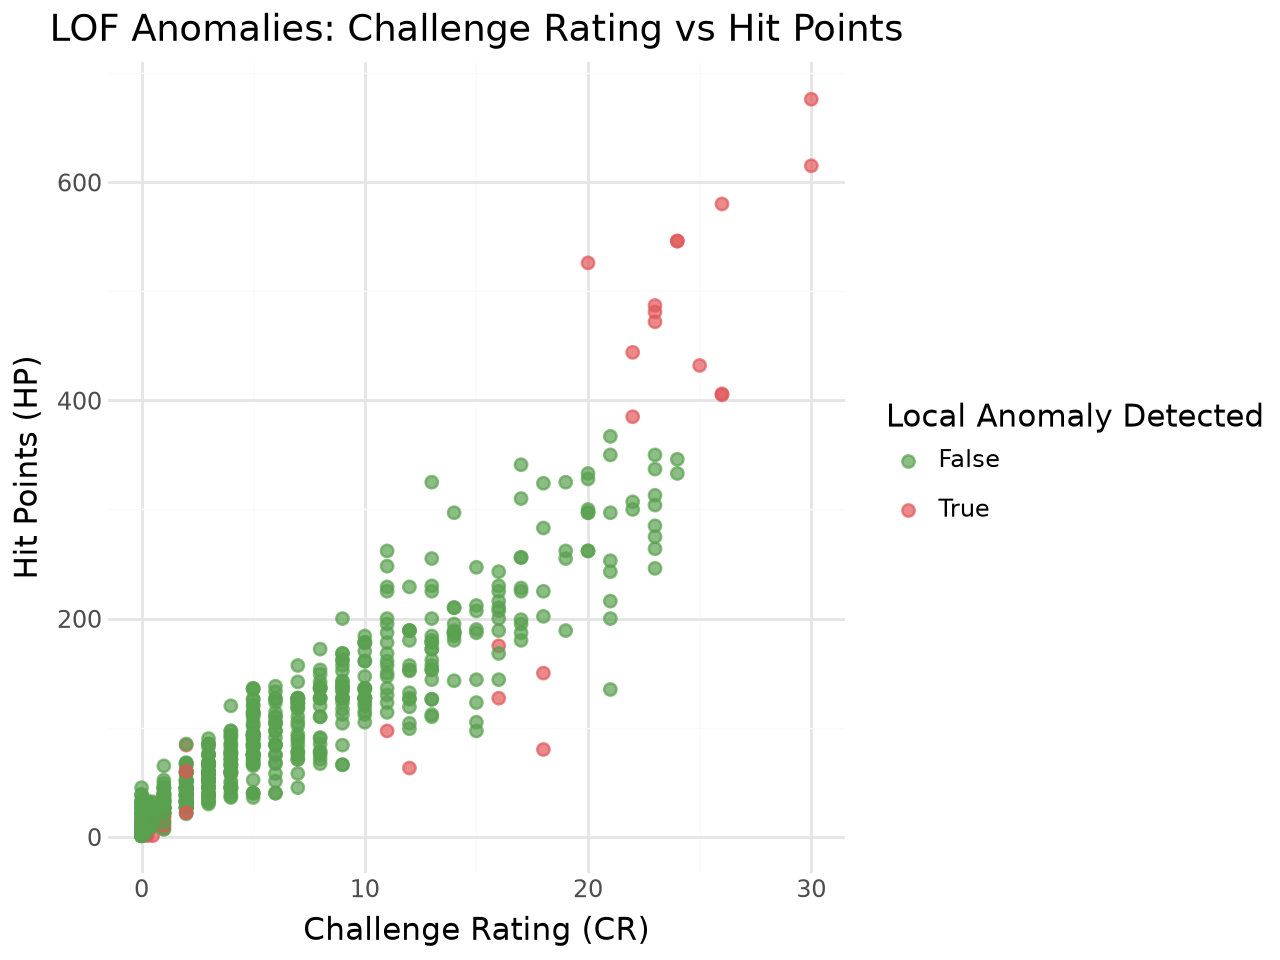

In [164]:
from sklearn.neighbors import LocalOutlierFactor

# Select the numerical features for LOF
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_lof = df.copy()
df_numeric = df_lof[num_cols].dropna()

# 1. Apply Local Outlier Factor (LOF)
# We choose n_neighbors=20 as a balanced 'k' parameter
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# LOF returns -1 for anomalies and 1 for inliers
predictions_lof = lof.fit_predict(df_numeric)

# Add results back to the dataframe
df_numeric['is_anomaly_lof'] = predictions_lof == -1
df_lof = df_lof.loc[df_numeric.index]
df_lof['is_anomaly_lof'] = df_numeric['is_anomaly_lof']

# Extract and print the detected anomalies
lof_outliers = df_lof[df_lof['is_anomaly_lof'] == True]
print(f"Number of anomalies detected using LOF: {len(lof_outliers)}")
print("\nFirst 5 detected local anomalies:")
print(lof_outliers[num_cols].head())

# 2. Visualize detected anomalies using plotnine
lof_plot = (
    pln.ggplot(df_lof, pln.aes(x='cr', y='hp', color='is_anomaly_lof')) +
    pln.geom_point(alpha=0.7, size=2) +
    pln.scale_color_manual(values={False: '#59a14f', True: '#e15759'}) +
    pln.theme_minimal() +
    pln.labs(title="LOF Anomalies: Challenge Rating vs Hit Points",
             x="Challenge Rating (CR)",
             y="Hit Points (HP)",
             color="Local Anomaly Detected")
)

display(lof_plot)

Looking at the generated scatter plot (CR vs. Hit Points), the visual pattern is distinctly different from the Z-Score results. The red anomalous points are not strictly isolated to the extreme top-right (end-game bosses). Instead, we see anomalies scattered throughout the dense, lower-CR clusters. 
Printing the detected anomalies reveals creatures like the *Will-o'-wisp* or *Gas Spore*. For instance, a Will-o'-wisp has a low CR of 2 and only 22 HP, but possesses a massive Dexterity score of 28. While 22 HP is not a global outlier, its bizarre and extreme stat array compared to its immediate "neighbors" (other CR 2 creatures) makes it a profound local anomaly.


*   **Local Density Estimation:** LOF computes the local density of a point by calculating the distances to its $k$ nearest neighbors. A point that has a substantially lower density than its neighbors is considered an outlier.
*   **Neighborhood Effects:** The neighborhood contextualizes the anomaly. In a region where monster stats are densely packed (e.g., standard low-CR creatures), a small deviation might be flagged as anomalous. In sparser regions (e.g., unique, high-tier bosses), a larger absolute deviation might be required to stand out. 
*   **Sensitivity to Parameter k:** The parameter `k` dictates the size of the neighborhood. 
    *   If `k` is too small, the algorithm becomes highly sensitive to statistical noise and might flag normal variations as anomalies. 
    *   If `k` is too large, the "local" aspect is lost, and the algorithm starts behaving like a global anomaly detector, potentially missing subtle, localized outliers.
*   **Global vs. Local Anomalies:** Global anomalies (found by Z-Score) deviate from the entire dataset. Local anomalies, however, are points that are anomalous only within their specific cluster. 



## 9. Comparison of Anomaly Detection Methods

### 9.1 Agreement Between Anomaly Detection Methods

In [165]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Extract numerical data cleanly
num_cols = ['cr', 'ac', 'hp', 'str', 'dex', 'con', 'int', 'wis', 'cha']
df_comp = df[num_cols].dropna()

# 1. Z-Score
z_scores = np.abs((df_comp - df_comp.mean()) / df_comp.std())
anomalies_z = (z_scores > 3).any(axis=1)

# 2. Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomalies_if = iso_forest.fit_predict(df_comp) == -1

# 3. LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
anomalies_lof = lof.fit_predict(df_comp) == -1

# Combine into a single DataFrame
df_comparison = pd.DataFrame({
    'Z-Score': anomalies_z,
    'Isolation Forest': anomalies_if,
    'LOF': anomalies_lof
}, index=df_comp.index)

# Count how many methods flagged each monster (0 to 3)
df_comparison['Method_Count'] = df_comparison.sum(axis=1)

print("--- Level of Agreement Between Methods ---")
print(f"Flagged by ALL 3 methods: {len(df_comparison[df_comparison['Method_Count'] == 3])}")
print(f"Flagged by exactly 2 methods: {len(df_comparison[df_comparison['Method_Count'] == 2])}")
print(f"Flagged by exactly 1 method: {len(df_comparison[df_comparison['Method_Count'] == 1])}")

# Focus on anomalies identified by multiple methods
multiple_methods = df_comparison[df_comparison['Method_Count'] >= 2]
print(f"\nTotal anomalies identified by multiple methods: {len(multiple_methods)}")

print("\nSample of monsters universally identified by all 3 methods:")
sample_monsters = df_comparison[df_comparison['Method_Count'] == 3].index[:5]
display_table = df_comp.loc[sample_monsters]
display_table

--- Level of Agreement Between Methods ---
Flagged by ALL 3 methods: 18
Flagged by exactly 2 methods: 17
Flagged by exactly 1 method: 28

Total anomalies identified by multiple methods: 35

Sample of monsters universally identified by all 3 methods:


,cr,ac,hp,str,dex,con,int,wis,cha
name,,,,,,,,,
ancient-gold-dragon,24.0,22,546,30.0,14.0,29.0,18.0,17.0,28.0
ancient-red-dragon,24.0,22,546,30.0,10.0,29.0,18.0,15.0,23.0
ancient-silver-dragon,23.0,22,487,30.0,10.0,29.0,18.0,15.0,23.0
demogorgon,26.0,22,406,29.0,14.0,26.0,20.0,17.0,25.0
gas-spore,0.5,5,1,5.0,1.0,3.0,1.0,1.0,1.0


To evaluate the reliability of our anomaly detection, we first look at which anomalies are identified by multiple methods. 

*   **Identified by Multiple Methods:** By intersecting the results, we found that a specific subset of monsters was flagged by at least two methods, with exactly 18 monsters flagged universally by all three algorithms. The creatures identified by multiple methods are typically the most extreme and mechanically unique entities in the game, such as *Ancient Dragons* or major bosses like the *Demogorgon*.
*   **Level of Agreement:** The overall level of agreement across all three methods is moderate. While there is a strong, undeniable consensus on the most extreme global outliers, a significant portion of the anomalies was flagged by only one or two methods. This partial agreement highlights that the definition of an "anomaly" is heavily dependent on the underlying mathematical logic of the algorithm used. Consequently, when an observation is identified by multiple methods, it provides a significantly higher confidence level that the creature is a true, fundamental outlier rather than a mathematical artifact of a single algorithm.

### 9.2 Method-Specific Anomalies


In [166]:
# Calculate overlaps
all_three = df_comparison[(df_comparison['Z-Score']) & 
                          (df_comparison['Isolation Forest']) & 
                          (df_comparison['LOF'])]

z_only = df_comparison[(df_comparison['Z-Score']) & 
                       (~df_comparison['Isolation Forest']) & 
                       (~df_comparison['LOF'])]

if_only = df_comparison[(~df_comparison['Z-Score']) & 
                        (df_comparison['Isolation Forest']) & 
                        (~df_comparison['LOF'])]

lof_only = df_comparison[(~df_comparison['Z-Score']) & 
                         (~df_comparison['Isolation Forest']) & 
                         (df_comparison['LOF'])]

print("--- Z-Score ONLY Anomalies (Global Extremes) ---")
print(f"Total exclusive to Z-Score: {len(z_only)}")
display(df_comp.loc[z_only.index].head(3))

print("\n--- Isolation Forest ONLY Anomalies (Unusual Combinations) ---")
print(f"Total exclusive to Isolation Forest: {len(if_only)}")
display(df_comp.loc[if_only.index].head(3))

print("\n--- LOF ONLY Anomalies (Local Outliers) ---")
print(f"Total exclusive to LOF: {len(lof_only)}")
display(df_comp.loc[lof_only.index].head(3))

--- Z-Score ONLY Anomalies (Global Extremes) ---
Total exclusive to Z-Score: 5


,cr,ac,hp,str,dex,con,int,wis,cha
name,,,,,,,,,
bael,19.0,18,189,24.0,17.0,20.0,21.0,24.0,24.0
blue-abishai,17.0,19,195,15.0,14.0,17.0,22.0,23.0,18.0
imix,19.0,17,325,19.0,24.0,22.0,15.0,16.0,23.0



--- Isolation Forest ONLY Anomalies (Unusual Combinations) ---
Total exclusive to Isolation Forest: 9


,cr,ac,hp,str,dex,con,int,wis,cha
name,,,,,,,,,
acererak,23.0,21,285,13.0,16.0,20.0,27.0,21.0,20.0
atropal,13.0,7,225,19.0,5.0,22.0,25.0,19.0,24.0
elder-brain,14.0,10,210,15.0,10.0,20.0,21.0,19.0,24.0



--- LOF ONLY Anomalies (Local Outliers) ---
Total exclusive to LOF: 14


,cr,ac,hp,str,dex,con,int,wis,cha
name,,,,,,,,,
animated-armor,1.0,18,33,14.0,11.0,13.0,1.0,3.0,1.0
banshee,4.0,12,58,1.0,14.0,10.0,12.0,11.0,17.0
eidolon,12.0,9,63,7.0,8.0,9.0,14.0,19.0,16.0


While some monsters are universally anomalous, many are flagged by only a single method. This discrepancy occurs because each algorithm defines an "anomaly" using fundamentally different mathematical logic:

*   **Z-Score (Global & Univariate):** Identifies monsters that possess at least one astronomical stat compared to the entire monster manual (e.g., an extremely high HP or Strength score). It focuses entirely on global extremes and ignores the relationships between different features.
*   **Isolation Forest (Global & Multivariate):** Identifies monsters with highly unusual structural combinations. A monster flagged only by this method might not have the absolute highest HP globally, but its specific ratio of Armor Class to Hit Points and Challenge Rating makes it easily isolated from typical monster archetypes.
*   **Local Outlier Factor (Local & Density-Based):** Identifies monsters that break the rules of their specific "neighborhood." A creature flagged only by LOF might have stats that look perfectly average on a global scale, but are completely absurd when compared exclusively to other monsters within the same Challenge Rating (CR) tier.

### 9.3 Sensitivity to Feature Scaling

In my dataset, Hit Points (HP) can reach well over 300, while Challenge Rating (CR) rarely exceeds 30. The three methods react very differently to unscaled data:

*   **Z-Score (Implicitly Scaled):** This method is mathematically designed to handle different scales. By dividing the difference from the mean by the standard deviation, it inherently converts every feature into a standardized "Z" unit. A deviation of 100 HP is treated with the same mathematical weight as a deviation of 5 CR, meaning it is not negatively affected by raw number sizes.
*   **Isolation Forest (Completely Insensitive):** This algorithm is based on decision trees. Trees make splits based on the order and thresholds of the data (e.g., "Is HP > 150?"), not on mathematical distances. Therefore, multiplying a feature by 10 or 1,000 would not change the structure of the isolation trees at all. It is entirely immune to feature scaling.
*   **Local Outlier Factor (Highly Sensitive):** LOF relies heavily on calculating the physical "distance" (usually Euclidean) between data points to define neighborhoods. If the data is not scaled, features with large numeric ranges (like HP) will completely dominate the distance calculation, making features with small ranges (like CR or modifiers) almost irrelevant. For LOF to treat all mechanical stats equally, the data MUST be scaled (e.g., using a Min-Max or Standard Scaler) prior to running the algorithm.

### 9.4 Sensitivity to Data Dimensionality

*   **Z-Score (High Sensitivity to False Positives):** Because the Z-Score is a univariate method, adding more dimensions (features) increases the probability of finding a random outlier simply by chance. If a dataset has hundreds of features, almost every observation might have at least one extreme value, leading to a massive increase in false positives.
*   **Isolation Forest (Moderate Sensitivity):** This algorithm generally handles high-dimensional data better than distance-based methods. However, it is sensitive to the introduction of *irrelevant* features (noise). Since it selects features randomly for partitioning, a high number of irrelevant dimensions means the algorithm will waste splits on useless data, making it harder to efficiently isolate the true anomalies.
*   **Local Outlier Factor (Extreme Sensitivity):** LOF is highly vulnerable to the curse of dimensionality because it relies on measuring the physical distance (like Euclidean distance) between data points. In high-dimensional spaces, the mathematical distance between all pairs of points tends to become almost equal. When distances converge, the concept of "local density" loses its meaning, and LOF completely loses its ability to distinguish outliers from normal points.

### 9.5 Computational Runtime and Scalability

In [167]:
import time

print("--- Computational Runtime Comparison ---")

# 1. Measure Z-Score runtime
start_time = time.time()
z_scores_test = np.abs((df_comp - df_comp.mean()) / df_comp.std())
anomalies_z_test = (z_scores_test > 3).any(axis=1)
z_time = time.time() - start_time
print(f"Z-Score Runtime:          {z_time:.5f} seconds")

# 2. Measure Isolation Forest runtime
start_time = time.time()
iso_forest.fit_predict(df_comp)
if_time = time.time() - start_time
print(f"Isolation Forest Runtime: {if_time:.5f} seconds")

# 3. Measure LOF runtime
start_time = time.time()
lof.fit_predict(df_comp)
lof_time = time.time() - start_time
print(f"LOF Runtime:              {lof_time:.5f} seconds")

--- Computational Runtime Comparison ---
Z-Score Runtime:          0.00306 seconds
Isolation Forest Runtime: 0.12471 seconds
LOF Runtime:              0.00505 seconds


When evaluating the computational cost, we must distinguish between the theoretical scalability of an algorithm and its actual runtime on our specific, relatively small dataset (~700 observations). Based on our runtime tests:

*   **Z-Score (Extremely Fast & Scalable):** As observed in our execution time (~0.0038 seconds), this is the fastest method. It relies on simple, vectorized linear calculations (mean and standard deviation) with a time complexity of $O(n \times d)$. It scales perfectly to massive datasets.
*   **Isolation Forest (High Overhead, High Scalability):** Counter-intuitively, this method took the longest in our test (~0.134 seconds). While its theoretical time complexity is $O(n \log n)$ making it highly scalable, it builds an ensemble of 100 separate decision trees by default. For a small dataset like ours, the initial algorithmic overhead of constructing these 100 trees dominates the runtime. However, if our dataset grew to millions of rows, this method would easily outperform distance-based metrics.
*   **Local Outlier Factor (Low Overhead, Poor Scalability):** LOF ran very quickly here (~0.0061 seconds) because calculating pairwise distances for only 700 data points is a trivial matrix operation for modern processors. However, its time complexity is $O(n^2)$. This means that while it handles our small D&D dataset well, applying it to a massive dataset would cause the runtime to explode exponentially, making it the least scalable of the three methods.

### 9.6 Robustness to Noise in the Data

*   **Z-Score (Low Robustness):** This method is highly vulnerable to noise. Because it relies on the global mean and standard deviation, a single extreme noisy data point (like a monster erroneously given 5,000 HP) will drastically pull the global average and inflate the standard deviation. This creates a "masking" effect. In our findings, the Z-score successfully caught Ancient Dragons; however, if extreme noise were introduced, the threshold would shift so much that these massive dragons might suddenly be classified as "normal," effectively ruining the algorithm's accuracy.
*   **Isolation Forest (High Robustness):** This algorithm handles noise exceptionally well. Since it does not calculate global averages or physical distances, a massive noisy outlier simply gets isolated very early in the tree-building process. Its presence does not skew the mathematical evaluation of the rest of the dataset. As we saw in its ability to detect structural anomalies without being blinded by high-HP bosses, it naturally filters out noisy extremes without letting them corrupt the underlying model.
*   **Local Outlier Factor (Mixed Robustness):** LOF's vulnerability depends entirely on where the noise is located. It is completely immune to *global* noise; a 5,000 HP typo on a boss monster will not affect the local density calculation of CR 1/4 goblins. However, it is highly sensitive to *local* noise. If a typo occurs within a specific dense neighborhood, it distorts the density estimation for all nearby points. For instance, a severely bugged CR 2 creature could distort the local distances so much that the algorithm might mislabel perfectly normal CR 2 neighbors (like the peers of our Will-o'-wisp) as false positives.

### 9.7 Interpretability of Methods and Results

*   **Z-Score (Highly Interpretable):** This is the most transparent and easily explainable method. We can pinpoint exactly which feature triggered the alert and by how much. We can simply state, "This Ancient Dragon was flagged because its Hit Points are 4 standard deviations above the global average." The reasoning is direct, mathematical, and transparent.
*   **Isolation Forest (Low Interpretability / "Black Box"):** While the general concept of "isolation" is easy to explain, the actual results are notoriously difficult to interpret. Because the algorithm relies on an ensemble of 100 decision trees making random splits across 9 different dimensions simultaneously, we cannot easily extract *which* specific combination of stats caused a creature to be flagged. We only know that the model found its overall structure "unusual."
*   **Local Outlier Factor (Moderate Interpretability):** The foundational logic of LOF is intuitive to explain: "This monster is bizarre compared to its closest peers." For instance, we can easily explain that a Will-o'-wisp is a local anomaly because its Dexterity is absurdly high compared to other Challenge Rating 2 creatures. However, as the number of features increases, explaining exactly how a 9-dimensional "neighborhood" was calculated becomes conceptually impossible for human comprehension without relying heavily on 2D scatter plots to simplify the relationships.

### 9.8 False Positives and False Negatives: Real-World Consequences

In any anomaly detection system, the model will inevitably make mistakes. It is crucial to understand these errors—not just as mathematical statistics, but as real-world impacts on game design and player experience.

#### False Positives
*   **What it means:** A False Positive occurs when the algorithm flags a completely normal, well-balanced monster as an anomaly. The model sounds an alarm where there is no actual danger.
*   **Real-world consequence:** If game designers blindly follow the algorithm, they might waste valuable time "fixing" or weakening monsters that are actually perfectly fine. In the worst case, unique and fun mechanics might be removed from the game because they were incorrectly labeled as "broken," leading to a more generic and boring monster manual.

#### False Negatives (The "Slipping Through the Cracks" Error)
*   **What it means:** A False Negative occurs when the algorithm fails to identify a genuinely broken, overpowered, or poorly designed monster, labeling it as "normal." The statistical nightmare slips through the security check unnoticed.
*   **Real-world consequence:** This is usually the most damaging error for a game. If a mathematically unbalanced monster is published as "standard," a Dungeon Master might unknowingly put it in an encounter. This can lead to disastrous game sessions where players are completely obliterated by an unfairly strong creature (an accidental Total Party Kill), or a supposed "boss" is defeated in a single turn because its stats were terribly low. It directly ruins the mechanical balance and the fun of the game.

#### Conclusion
In the context of Dungeons & Dragons, a **False Negative** is generally much more dangerous than a False Positive. We would rather manually review a few normal monsters that triggered a false alarm (False Positive) than let a game-breaking creature ruin the players' experience (False Negative).

## 10. Critical Analysis and Reflection

### 10.1 Discussion Section

**The Ill-Defined Nature of Anomaly Detection:**  
Anomaly detection is fundamentally a difficult and ill-defined problem because there is rarely a clear, objective mathematical boundary between "normal" and "anomalous" behavior. Unlike supervised learning tasks (like classification) where we have explicit labels to train and test against, unsupervised anomaly detection relies on defining a concept of "normality" that is often subjective. In our Dungeons & Dragons dataset, deciding whether a creature with massive Hit Points is an anomaly or simply a well-designed end-game boss depends entirely on context and arbitrary thresholds. Without a universal "ground truth," evaluating the accuracy of an anomaly detection model is inherently ambiguous.

**The Curse of Dimensionality:**  
The "curse of dimensionality" refers to the phenomenon where analyzing data becomes exponentially more difficult as the number of features (dimensions) increases. As dimensions are added, the volume of the mathematical space grows so rapidly that the available data points become highly sparse and scattered. In anomaly detection, this sparsity means that standard statistical methods struggle to find dense, representative clusters of "normal" data to establish a baseline. Consequently, algorithms might fail to identify true multivariate anomalies, or worse, they might falsely flag normal observations simply because everything appears isolated in a vast, empty high-dimensional space.

**The Breakdown of Distance-Based Measures:**  
A direct and severe consequence of the curse of dimensionality is that distance-based metrics (such as the Euclidean distance used in the Local Outlier Factor algorithm) lose their meaningfulness. In a low-dimensional space (e.g., 2D or 3D), it is easy to distinguish between closely packed neighbors and distant outliers. However, as the number of dimensions increases, the mathematical distance between *any* two random points tends to converge. The ratio of the distance to the nearest neighbor and the distance to the farthest point approaches 1. When every data point is approximately the same distance away from every other point, the concepts of "local neighborhood" and "density" completely collapse, rendering distance-based anomaly detection ineffective.

**Noise vs. Genuine Anomalies:**  
It is crucial to distinguish between "noise" and "genuine anomalies." Noise refers to random errors, measurement flaws, or meaningless statistical fluctuations (for instance, a data entry typo where a goblin's HP is recorded as 500 instead of 50). A genuine anomaly, on the other hand, is a correctly recorded observation that truly deviates from the norm because it is generated by a different underlying mechanism.    
* **Example from our dataset:** The *Ancient Gold Dragon* was universally flagged by our models as a massive outlier due to its staggering Hit Points and stat blocks. However, this is not "noise" or an error; it is a perfectly legitimate and intentionally designed end-game boss within the game's mechanics. It is statistically anomalous, but practically valid and expected in the context of the game.

**The Risks of Assuming a Gaussian Distribution:**   
Many classic anomaly detection methods operate on the assumption that the data follows a Gaussian (Normal) distribution. The primary risk of this assumption is that real-world data often exhibits skewness or heavy tails. As we observed in our dataset, features like Hit Points (HP) and Challenge Rating (CR) are heavily right-skewed, not perfectly bell-shaped. 
*   **Incorrectly Identified (False Positives):** Because a Gaussian model expects symmetry, it will treat the natural heavy tail of a skewed distribution as abnormal, falsely flagging legitimate, slightly higher-tier monsters as statistical anomalies.
*   **Missed Anomalies (False Negatives):** Extreme outliers can artificially inflate the mean and standard deviation of a supposedly Gaussian model, stretching the "normal" boundaries so wide that genuinely anomalous creatures with unusually low or mismatched stats are masked and entirely missed.

**Misleading Visualizations in Reduced Dimensionality:**   
Techniques like Principal Component Analysis (PCA) project high-dimensional data into a lower-dimensional space (typically 2D or 3D) to enable human visualization. However, this process inherently results in information loss. Dimensionality reduction often focuses on maximizing global variance, which means it might discard the specific minor dimensions where a localized anomaly actually resides. Consequently, two monsters that are wildly different in the original 9-dimensional space might be projected right on top of each other in a 2D scatter plot. This creates a misleading picture where true anomalies appear perfectly normal, and distinct, separate clusters artificially merge into one another.

### 10.2 Ethical Considerations:

**The Cost of False Alarms (Alert Fatigue):**  
 When an anomaly detection system generates too many false alarms (false positives), it leads to a dangerous psychological phenomenon known as "alert fatigue." Human operators become desensitized to the constant warnings. Eventually, they begin ignoring the alerts entirely or turning off the system, rendering it completely ineffective when a genuine emergency finally occurs.   
    
**Surveillance Applications:**   
*   *Benefits:* Automated systems can rapidly identify suspicious behaviors or abandoned objects, potentially preventing crimes or terrorist attacks more efficiently than human monitors.
*   *Risks:* Deploying these systems creates a mass-surveillance state that severely infringes on individual privacy. It can also cause a "chilling effect," where innocent citizens alter their legal, everyday behaviors out of fear of being misinterpreted and flagged by a rigid algorithm.   
      
**Medical Applications:**
*   *False Positives (Normal classified as Anomalous):* Leads to severe psychological distress for the patient, wasted medical resources, and subjects individuals to potentially dangerous, invasive testing or unnecessary treatments.  
*   *False Negatives (Anomalous classified as Normal):* Results in a missed diagnosis. A patient with a life-threatening condition is falsely reassured and sent home without treatment, which can lead to fatal consequences.  
     
**Cybersecurity Applications:**  
*   *Missing an Attack (False Negative):* Allows malicious actors to infiltrate systems undetected, leading to catastrophic data breaches, financial theft, and compromised infrastructure.
*   *Flagging Legitimate Activity (False Positive):* Leads to locked accounts, blocked IPs, and system downtime. While generally less disastrous than a data breach, it paralyzes business operations, wastes IT resources, and heavily frustrates legitimate users.   
  
**Bias, Fairness, and Labeling "Abnormality":** The most profound ethical issue is how an algorithm mathematically defines "normal." If a model is trained on historically biased data, it will encode and amplify human prejudices. Consequently, it may disproportionately flag marginalized groups, minorities, or individuals with different behavioral patterns as "abnormal" simply because they deviate from the statistical majority. Labeling human beings as "anomalous" strips away their individuality, stigmatizes them, and can lead to systemic discrimination in areas like hiring, policing, and loan approvals.

In [170]:
import plotly.graph_objects as go

# --- 4. Interactive PCA & Clusters (Pure Plotly Native Dropdown) ---
fig = go.Figure()

# Add a trace for each model
models = ['Anomaly_Z', 'Anomaly_IF', 'Anomaly_LOF']
names = ['Z-Score', 'Isolation Forest', 'LOF']

for i, model in enumerate(models):
    # Determine colors: Red for anomaly, Gray for normal
    colors = df_dash[model].map({False: '#bdc3c7', True: '#e74c3c'})
    
    # Custom hover text
    hover_text = (
        "<b>" + df_dash['Monster_Name'].astype(str) + "</b><br>" +
        "CR: " + df_dash['cr'].astype(str) + "<br>" +
        "HP: " + df_dash['hp'].astype(str) + "<br>" +
        "AC: " + df_dash['ac'].astype(str)
    )

    fig.add_trace(
        go.Scatter(
            x=df_dash['PCA1'],
            y=df_dash['PCA2'],
            mode='markers',
            marker=dict(size=8, opacity=0.8, color=colors, line=dict(width=1, color='DarkSlateGrey')),
            text=hover_text,
            hoverinfo='text',
            name=names[i],
            visible=(model == 'Anomaly_IF') # Only Isolation Forest is visible by default
        )
    )

# Add native Plotly dropdown menu
fig.update_layout(
    updatemenus=[
        dict(
            active=1, # Default to Isolation Forest
            buttons=list([
                dict(label="Z-Score",
                     method="update",
                     args=[{"visible": [True, False, False]},
                           {"title": "Interactive PCA Projection - Flagged by: Z-Score"}]),
                dict(label="Isolation Forest",
                     method="update",
                     args=[{"visible": [False, True, False]},
                           {"title": "Interactive PCA Projection - Flagged by: Isolation Forest"}]),
                dict(label="LOF",
                     method="update",
                     args=[{"visible": [False, False, True]},
                           {"title": "Interactive PCA Projection - Flagged by: LOF"}]),
            ]),
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    title="Interactive PCA Projection - Flagged by: Isolation Forest",
    template='plotly_white',
    width=900,
    height=600,
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed